<div style="background-color:#c3faf6; color:#222222; border:3px solid #bee5eb; padding:12px 14px; border-radius:10px; margin:10px 0;">

# How Facial Recognition Bias Compounds Across Race and Gender as Subjects Age


**CS109b Group #103**:Jenni Arakaki, Laine Roper, Arian Nzioka
**Project #18**: 

Project Proposal: https://drive.google.com/file/d/1yRPxpvg4jQc8gwzPgP_ptiSU6Qs4qmL1/view

## Problem Statement

The objective of this project is to train and optimize a visual model to reduce facial recognition bias across age, race, and gender. 
Facial features vary across race and gender as subjects age
A naive model will fail to capture these nuances
Our model will try to reduce this bias

Goal 1: Investigate what bias in a baseline model that predicts age and gender

Goal 2: Train additional models that try to mitigate this bias



MS2 Summary: preprocessing, duplicate removal, misentry idenitification, visualization of dataset imbalance, umap and pca of raw pixels (now changed in MS3), first pass ResNet model. 


In [35]:
!pip install kagglehub
# Standard library
import os
import gc
import time
import warnings

# Numerical computing and data processing
import numpy as np
import pandas as pd
import random
from pathlib import Path
from collections import Counter
import zipfile

# external utilities
import kagglehub
import hashlib

# Visualization
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
from torchvision import transforms

# UMAP
#import umap
from tqdm import tqdm
import umap
from umap import UMAP

Defaulting to user installation because normal site-packages is not writeable


In [36]:
# Suppress warnings
warnings.filterwarnings('ignore')

### Downloading/Accessing data:
1) Download data from https://www.kaggle.com/datasets/jangedoo/utkface-new.
2) kagglehub library downloads and stores data in `./cache` directory for reproducibility

In [37]:
path = kagglehub.dataset_download("jangedoo/utkface-new")
utk_path = next(Path(path).rglob("UTKFace"))

print("Path Exists  :", utk_path.exists())
print(f"Dataset downloaded to:", utk_path)

Path Exists  : True
Dataset downloaded to: /shared/home/lar160/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/UTKFace


In [38]:
# put image paths into Dataset, make all RGB, count how many
class FlatImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.files   = [f for f in self.img_dir.rglob("*")
                        if f.name.endswith(".jpg")
                        or f.name.endswith(".jpeg")
                        or f.name.endswith(".png")]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.files[idx].name

dataset = FlatImageDataset(utk_path)

size = 0
img_count = 0
for dirpath, dirnames, filenames in os.walk(utk_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        size += os.path.getsize(fp)
        img_count += 1

print(f"Number of images : {img_count}")
print(f"Size on disk   : {size / (1024**2):.2f} MB")

Number of images : 23708
Size on disk   : 114.43 MB


### Search for and Remove Duplicate Images

Here we load each image, convert its pixel data into a byte representation, and computes an MD5 hash that acts like a unique fingerprint for the image. We use the hashes to identify and remove duplicate images, keeping only the first occurrence of each. Other than this removal we are currently using the entire dataset.

### Labels:

The UTK dataset is a facial close-up collection of labeled images. Each image data features is embedded in the file name, formated like [age]_[gender]_[race]_[date&time].jpg

- `age` is an integer from `0`to `116`, indicating the age
- `gender` is either 0 `male` or 1 `female`
- `race` is an integer from 0 to 4, denoting `White`, `Black`, `Asian`, `Indian`, and `Others` (like `Hispanic`, `Latino`, `Middle Eastern`).
- `date&time` is in the format of `yyyymmddHHMMSSFFF`, showing the date and time an image was collected to UTKFace

In [39]:
CACHE_FILE = "nodup_dataset.pkl"

# ============================================================
# LOAD CLEANED DATASET IF IT EXISTS
# ============================================================
if os.path.exists(CACHE_FILE):

    print(f"Loading non-dup dataset from: {CACHE_FILE}")
    df = pd.read_pickle(CACHE_FILE)
    print(f"Loaded dataset size : {len(df)}")

else:

    print("No cached dataset found.")
    print("Hashing images...")

    def hash_image(img):
        """Generate MD5 hash from image pixels."""
        return hashlib.md5(np.array(img).tobytes()).hexdigest()

    # --- compute hashes directly from image files ---
    hashes = []
    images = []

    for p in dataset.files:
        img = Image.open(p).convert("RGB")
        images.append(img)
        hashes.append(hash_image(img))

    df = pd.DataFrame({
        "path": dataset.files,
        "image": images,
        "hash": hashes
    })

    # ============================================================
    # DUPLICATE ANALYSIS
    # ============================================================
    dup_mask = df.duplicated(subset='hash', keep=False)
    duplicates = df[dup_mask].copy()

    n_before = len(df)
    num_removed = df.duplicated(subset='hash', keep='first').sum()

    print(f"Total images before : {n_before}")
    print(f"Duplicate images found : {len(duplicates)}")
    print(f"Duplicate images removed : {num_removed}")

    # ============================================================
    # VISUALIZE DUPLICATES
    # ============================================================
    dup_groups = list(duplicates.groupby('hash'))

    if len(dup_groups) > 0:

        n_groups = min(3, len(dup_groups))
        cols = 4

        fig, axes = plt.subplots(
            n_groups,
            cols,
            figsize=(10, 3 * n_groups)
        )

        if n_groups == 1:
            axes = [axes]

        for row_i, (hash_val, group) in enumerate(dup_groups[:n_groups]):

            group = group.reset_index(drop=True)

            for col_i in range(cols):

                ax = axes[row_i][col_i] if n_groups > 1 else axes[col_i]

                if col_i < len(group):

                    r = group.iloc[col_i]

                    name = os.path.basename(str(r['path']))
                    short_name = (
                        name[:22] + "..."
                        if len(name) > 22 else name
                    )

                    ax.imshow(r['image'])
                    ax.set_title(short_name, fontsize=7)

                ax.axis('off')

        plt.suptitle("Duplicate Image Groups", fontsize=12)
        plt.tight_layout()
        plt.subplots_adjust(hspace=0.5, wspace=0.3)
        plt.show()

    # ============================================================
    # REMOVE DUPLICATES (keep one copy of each)
    # ============================================================
    df = df.drop_duplicates(
        subset='hash',
        keep='first'
    ).reset_index(drop=True)

    print("\nDuplicates Removed.")
    print(f"Non-duplicated dataset size : {len(df)}")

    # ============================================================
    # SAVE CLEANED DATASET
    # ============================================================
    df.to_pickle(CACHE_FILE)

    print(f"Saved non-dup dataset to: {CACHE_FILE}")

Loading non-dup dataset from: nodup_dataset.pkl
Loaded dataset size : 23318


In [40]:
# ============================================================
# ADD LABELS TO CLEANED DATAFRAME
# ============================================================

def parse_utk_filename(filename):
    parts = filename.split("_")

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
        return age, gender, race
    except:
        return None

# parse labels from filenames
labels = []

for p in df["path"]:
    parsed = parse_utk_filename(os.path.basename(str(p)))

    if parsed is None:
        labels.append((None, None, None))
    else:
        labels.append(parsed)

df[["age", "gender", "race"]] = pd.DataFrame(
    labels,
    index=df.index
)

# remove invalid rows if any
df = df.dropna(subset=["age", "gender", "race"]).reset_index(drop=True)

# optional: convert to int
df["age"] = df["age"].astype(int)
df["gender"] = df["gender"].astype(int)
df["race"] = df["race"].astype(int)

# ============================================================
# PYTORCH DATASET
# ============================================================

class DFDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = row["image"]

        if self.transform:
            img = self.transform(img)

        return (
            img,
            torch.tensor(row["age"]),
            torch.tensor(row["gender"]),
            torch.tensor(row["race"])
        )

transform = transforms.Compose([
    transforms.ToTensor(),
])

clean_dataset = DFDataset(df, transform=transform)

print(f"Clean dataset size: {len(clean_dataset):,} images")

Clean dataset size: 23,315 images


## EDA

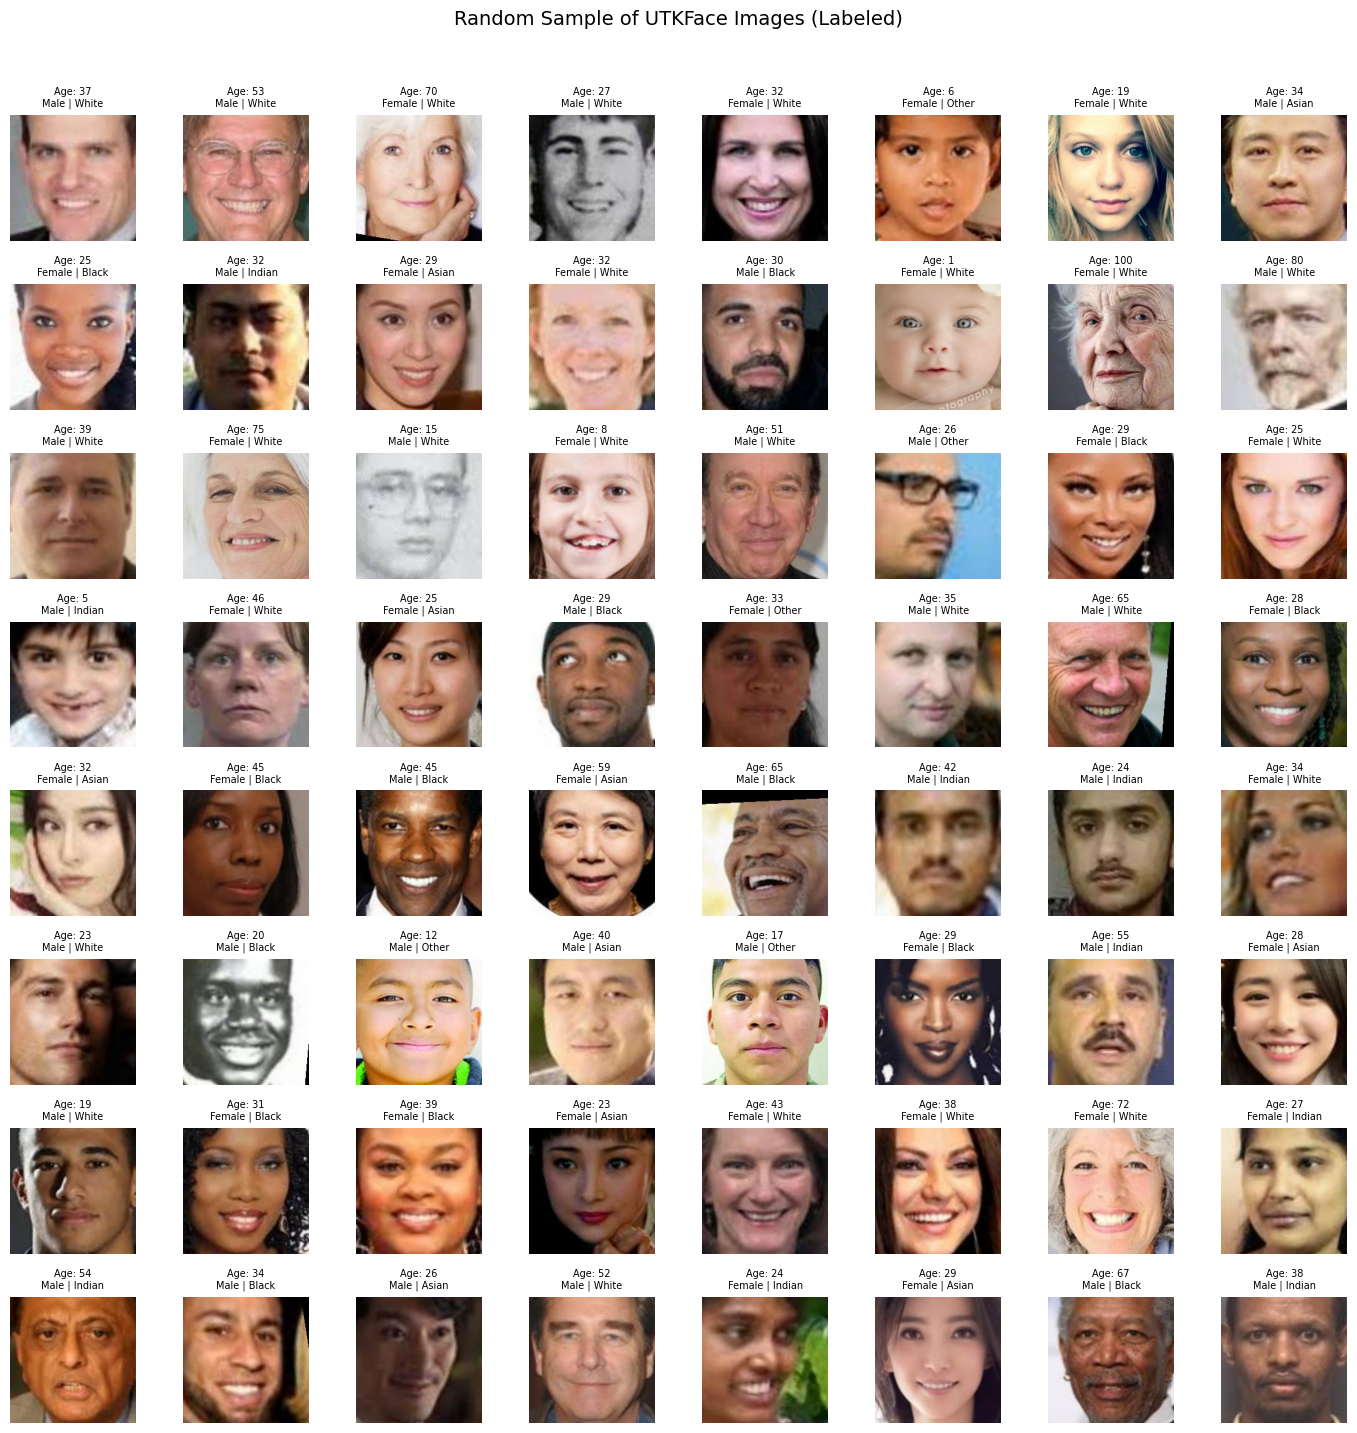

In [41]:
SEED = 42

gender_map = {
    0: "Male",
    1: "Female"
}

race_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Other"
}

# sample from dataframe
sample_df = df.sample(64, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(8, 8, figsize=(14, 14))
axes = axes.ravel()

for i, row in sample_df.iterrows():
    ax = axes[i]

    ax.imshow(row["image"])

    gender_str = gender_map.get(row["gender"], "Unknown")
    race_str   = race_map.get(row["race"], "Unknown")

    ax.set_title(
        f"Age: {row['age']}\n{gender_str} | {race_str}",
        fontsize=7
    )
    ax.axis("off")

plt.suptitle("Random Sample of UTKFace Images (Labeled)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Age range: 1 – 116


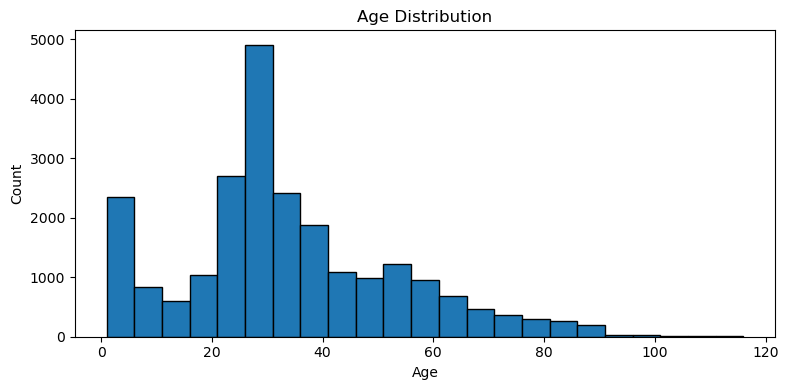


Age Group Counts:
age_group
child          3251
teen           1192
young_adult    9534
adult          6696
older_adult    2642
Name: count, dtype: int64


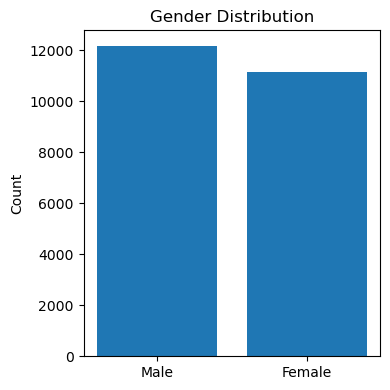

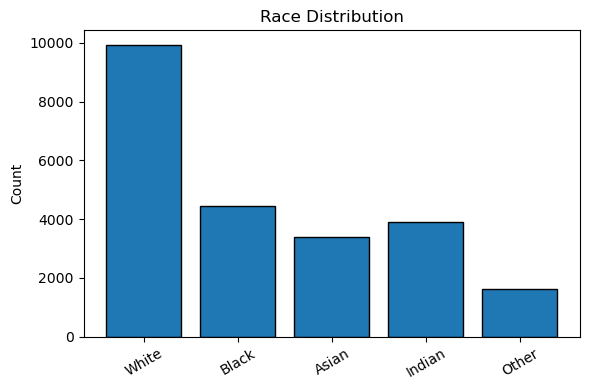

In [42]:
gender_map = {
    0: "Male",
    1: "Female"
}

race_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Other"
}

# --- basic stats ---
ages    = df["age"].tolist()
genders = df["gender"].tolist()
races   = df["race"].tolist()

age_max = df["age"].max()
age_min = df["age"].min()

print(f"Age range: {age_min} – {age_max}")

# =========================================================
# AGE DISTRIBUTION
# =========================================================
plt.figure(figsize=(8, 4))
plt.hist(ages, bins=range(age_min, age_max + 1, 5), edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- age groups ---
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 19, 35, 60, 120],
    labels=["child", "teen", "young_adult", "adult", "older_adult"],
    right=False
)

print("\nAge Group Counts:")
print(df["age_group"].value_counts().sort_index())

# =========================================================
# GENDER DISTRIBUTION
# =========================================================
gender_counts = Counter(genders)

plt.figure(figsize=(4, 4))
plt.bar(
    [gender_map[0], gender_map[1]],
    [gender_counts.get(0, 0), gender_counts.get(1, 0)]
)
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# =========================================================
# RACE DISTRIBUTION (LABELED)
# =========================================================
race_counts = Counter(races)

race_labels = [race_map[i] for i in range(5)]
race_values = [race_counts.get(i, 0) for i in range(5)]

plt.figure(figsize=(6, 4))
plt.bar(race_labels, race_values, edgecolor="black")
plt.title("Race Distribution")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

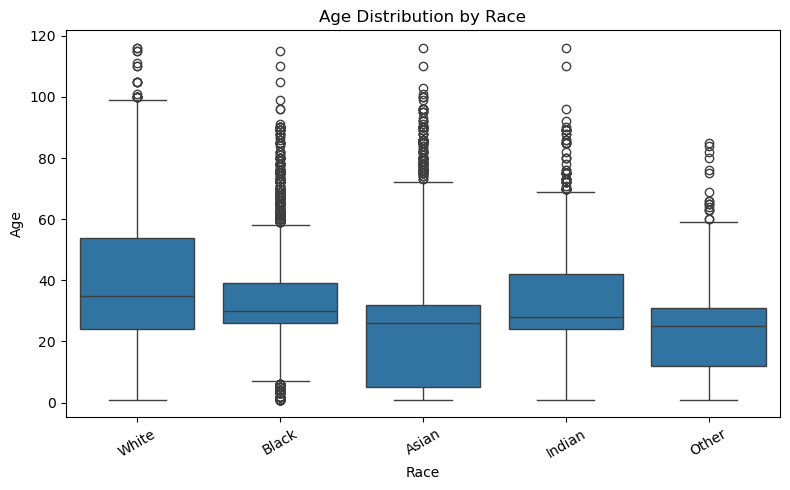

In [43]:
df["race_label"] = df["race"].map(race_map)
race_order = ["White", "Black", "Asian", "Indian", "Other"]

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="race_label",
    y="age",
    data=df,
    order=race_order
)

plt.title("Age Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Age")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

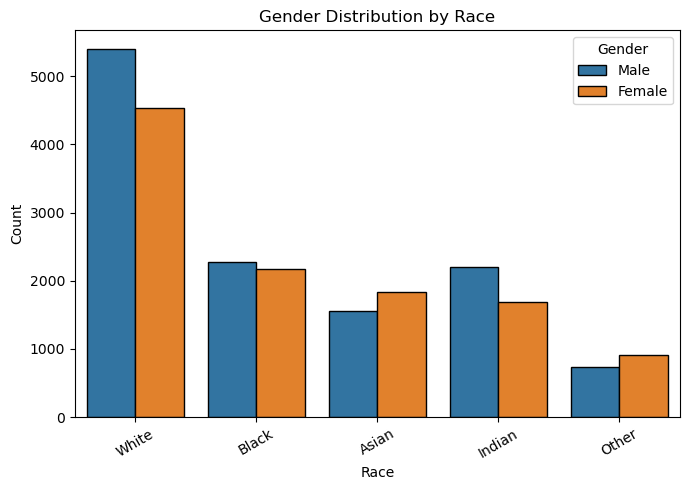

In [44]:
gender_order = ["Male", "Female"]
df["gender_label"] = df["gender"].map(gender_map)

plt.figure(figsize=(7, 5))
sns.countplot(
    x="race_label",
    hue="gender_label",
    data=df,
    order=race_order,
    hue_order=gender_order,
    edgecolor="black"
)

plt.title("Gender Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

### Key EDA Takeaways

#### 1. Gender distribution is relatively balanced
The dataset contains ~52% male and ~48% female samples

This indicates minimal gender imbalance overall

However, this balance does not guarantee fairness across subgroups (e.g., within each race or age group)

#### 2. Significant racial imbalance exists
White faces dominate (~42.5%)

Other groups are underrepresented:

- Black: ~19%
- Indian: ~16.8%
- Asian: ~14.5%
- Others: ~7.1%

#### 3. Age distribution is skewed (non-uniform)
Strong concentration in young adults (20–35)

Noticeable spike in very young ages (children/babies)

Teens are underrepresented

Gradual decline in samples for older ages

#### 4. Age distribution differs across gender
Males have a higher median age than females

Male age distribution is shifted older overall

Females are more concentrated in younger ranges

#### 5. Age distribution differs across race (important)
White group appears to have:

- higher median age
- wider spread

Other groups (e.g., Asian, Others) skew younger
Some races have fewer older individuals

#### 6. Gender imbalance varies across races
Some races (e.g., Indian) have more males than females

Others are more balanced

“Others” category is small and uneven

## Baseline Model ResNet Training

### Train val test split

Stratifying so each the proportions of each split match the proportions in the entire dataset.

Because some fine-grained age × race × gender subgroups contained too few samples for reliable stratified splitting, we stratified by race and gender only, while reserving age bins for downstream fairness evaluation.

Our model predicts age (continuous) and gender (binary) via two different heads attached to ResNet18. For analysis of performance, we bin the predicted ages, especially to see the effect of a low number of teen training images. We use ResNet for it's simple architecture. 

Our metrics evaluate model performance across demographic subgroups by breaking predictions into intersections of race, gender, and age bins. For gender classification, we compute subgroup inaccuracy and for age regression we use mean absolute error (MAE) to measure prediction distance from the true age. By structuring results as heatmaps over group combinations, we can directly compare whether errors are uniformly distributed or concentrated in specific populations, revealing potential bias or performance disparities.

In [73]:
SEED = 42

def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # deterministic CUDA behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # stricter determinism
    torch.use_deterministic_algorithms(True)

set_seed(SEED)
    
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)
#reproducibility ^^^^^^^

labels = ["0_5",      # infants / toddlers
          "5_13",     # children
          "13_20",    # teens
          "21_40",
          "41_60",
          "61_80",
          "80_plus"
]

df["eval_age_bin"] = pd.cut(
    df["age"],
    bins = [0, 5, 13, 20, 40, 60, 80, 120],
    labels = labels,
    include_lowest=True
)

# simple stratification key
df["stratify_key"] = (
    df["race"].astype(str) + "_" +
    df["gender"].astype(str) + "_"
)

# remove very tiny groups if stratification breaks
valid_keys = df["stratify_key"].value_counts()
valid_keys = valid_keys[valid_keys >= 2].index
df_split = df[df["stratify_key"].isin(valid_keys)].copy()
df_split = df_split.sample(frac=1, random_state=SEED).reset_index(drop=True) #shuffles rows the same every 
                                                                            #time and cleans up index

train_df, temp_df = train_test_split(
    df_split,
    test_size=0.30,
    random_state=SEED,
    stratify=df_split["stratify_key"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["stratify_key"]
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 16320
Validation size: 3497
Test size: 3498


In [74]:
class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # already a PIL image
        image = row["image"]

        if self.transform:
            image = self.transform(image)

        age = torch.tensor(row["age"], dtype=torch.float32)
        gender = torch.tensor(row["gender"], dtype=torch.float32)

        race = str(row["race"])
        age_bin = str(row["eval_age_bin"])

        return image, age, gender, race, age_bin

In [75]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225] #normalize

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# dataloaders
train_dataset = UTKFaceDataset(train_df, transform=train_transform)
val_dataset = UTKFaceDataset(val_df, transform=val_transform)
test_dataset = UTKFaceDataset(test_df, transform=test_transform)

train_loader = DataLoader( #changed for seed
    train_dataset,
    batch_size=64,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=g,
    num_workers=0
)
val_loader = DataLoader( #changed for seed
    val_dataset,
    batch_size=64,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=g,
    num_workers=0
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)
    
class MultiTaskResNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.age_head = nn.Linear(in_features, 1)
        self.gender_head = nn.Linear(in_features, 1)

    def forward(self, x, return_features=False):
        features = self.backbone(x)

        age_pred = self.age_head(features).squeeze(1)
        gender_logit = self.gender_head(features).squeeze(1)

        if return_features:
            return age_pred, gender_logit, features

        return age_pred, gender_logit
    
def extract_embeddings(model, loader, device):
    model.eval()

    embeddings = []
    age_preds = []
    gender_preds = []
    age_bins = []
    races = []
    genders = []

    with torch.no_grad():
        for images, ages, gender, race, age_bin in loader:
            images = images.to(device)

            age_pred, gender_logit, features = model(images, return_features=True)

            gender_pred = (torch.sigmoid(gender_logit) >= 0.5).float()

            embeddings.append(features.cpu())
            age_preds.append(age_pred.cpu())
            gender_preds.append(gender_pred.cpu())

            age_bins.extend(age_bin)
            races.extend(race)
            genders.extend(gender)

    return {
        "embeddings": torch.cat(embeddings),
        "age_pred": torch.cat(age_preds),
        "gender_pred": torch.cat(gender_preds),
        "age_bin": np.array(age_bins),
        "race": np.array(races),
        "gender": np.array(genders)
    }

def train_one_epoch(model, loader, optimizer, age_criterion, gender_criterion, device):
    model.train()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0

    for images, ages, genders, _, _ in tqdm(loader, desc="Training"):
        images = images.to(device)
        ages = ages.to(device)
        genders = genders.to(device)

        optimizer.zero_grad()

        age_pred, gender_logit = model(images)

        age_loss = age_criterion(age_pred, ages)
        gender_loss = gender_criterion(gender_logit, genders)

        loss = age_loss + gender_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_age_loss += age_loss.item() * images.size(0)
        total_gender_loss += gender_loss.item() * images.size(0)

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n
    }

def evaluate(model, loader, age_criterion, gender_criterion, device):
    model.eval()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0

    all_age_preds = []
    all_ages = []
    all_gender_preds_list = []
    all_genders = []

    with torch.no_grad():
        for images, ages, genders, _, _ in loader:
            images = images.to(device)
            ages = ages.to(device)
            genders = genders.to(device)

            age_pred, gender_logit = model(images)

            age_loss = age_criterion(age_pred, ages)
            gender_loss = gender_criterion(gender_logit, genders)
            loss = age_loss + gender_loss

            total_loss += loss.item() * images.size(0)
            total_age_loss += age_loss.item() * images.size(0)
            total_gender_loss += gender_loss.item() * images.size(0)

            gender_preds = (torch.sigmoid(gender_logit) >= 0.5).float()

            all_age_preds.append(age_pred.cpu())
            all_ages.append(ages.cpu())
            all_gender_preds_list.append(gender_preds.cpu())
            all_genders.append(genders.cpu())

    # safety check (prevents silent crashes)
    if len(all_gender_preds_list) == 0:
        raise RuntimeError("No validation predictions collected. Check DataLoader.")

    all_age_preds = torch.cat(all_age_preds)
    all_ages = torch.cat(all_ages)
    all_gender_preds = torch.cat(all_gender_preds_list)
    all_genders = torch.cat(all_genders)

    age_mae = torch.mean(torch.abs(all_age_preds - all_ages)).item()
    gender_acc = (all_gender_preds == all_genders).float().mean().item()

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n,
        "age_mae": age_mae,
        "gender_acc": gender_acc
    }
    
def compute_group_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    acc = (tp + tn) / len(y_true)
    fpr = fp / (fp + tn + 1e-8)
    fnr = fn / (fn + tp + 1e-8)

    return acc, fpr, fnr

In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

resnet_model = MultiTaskResNet().to(device)

age_criterion = nn.L1Loss()
gender_criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)
num_epochs = 10


# =========================
# TRAINING LOOP
# =========================
CHECKPOINT_PATH = "resnet_baseline_checkpoint.pt"
BEST_MODEL_PATH = "best_resnet_baseline.pt"

# =========================
# LOAD EXISTING CHECKPOINT
# =========================
if os.path.exists(CHECKPOINT_PATH):

    print("Checkpoint found. Loading saved model/history...")

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    resnet_model.load_state_dict(checkpoint["model_state"])

    history = checkpoint["history"]

    print("Skipping training.")

else:

    print("No checkpoint found. Starting training...")

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_age_mae": [],
        "val_gender_acc": []
    }

    best_val_mae = float("inf")
    best_gender_acc = 0.0

    start_time = time.time()

    # =========================
    # TRAINING LOOP
    # =========================
    for epoch in range(num_epochs):

        train_metrics = train_one_epoch(
            resnet_model,
            train_loader,
            optimizer,
            age_criterion,
            gender_criterion,
            device
        )

        val_metrics = evaluate(
            resnet_model,
            val_loader,
            age_criterion,
            gender_criterion,
            device
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_age_mae"].append(val_metrics["age_mae"])
        history["val_gender_acc"].append(val_metrics["gender_acc"])

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Age MAE: {val_metrics['age_mae']:.2f} | "
            f"Gender Acc: {val_metrics['gender_acc']:.3f}"
        )

        # ---- save best model ----
        if (
            val_metrics["age_mae"] < best_val_mae or
            (
                abs(val_metrics["age_mae"] - best_val_mae) < 1e-4 and
                val_metrics["gender_acc"] > best_gender_acc
            )
        ):

            best_val_mae = val_metrics["age_mae"]
            best_gender_acc = val_metrics["gender_acc"]

            torch.save(
                resnet_model.state_dict(),
                BEST_MODEL_PATH
            )

            print("→ Saved new best model")

    # =========================
    # SAVE CHECKPOINT
    # =========================
    torch.save({
        "model_state": resnet_model.state_dict(),
        "history": history,
        "config": {
            "img_size": IMG_SIZE,
            "seed": SEED
        }
    }, CHECKPOINT_PATH)

    end_time = time.time()

    print(f"\nTraining time: {(end_time - start_time)/60:.2f} minutes")
    print("Training Complete")

Checkpoint found. Loading saved model/history...
Skipping training.


In [77]:
emb_outputs = extract_embeddings(resnet_model, test_loader, device)

# save embeddings
np.save("test_embeddings_baseline.npy", emb_outputs["embeddings"].numpy())
print("Embedding shape:", emb_outputs["embeddings"].shape)

Embedding shape: torch.Size([3498, 512])


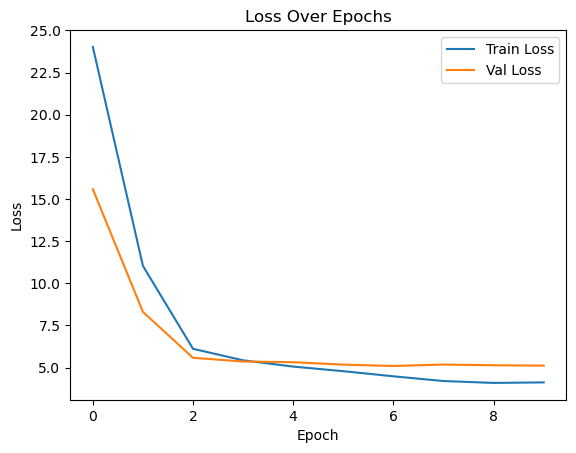

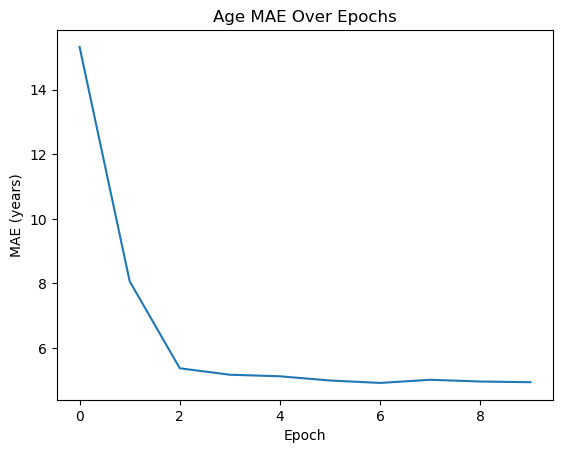

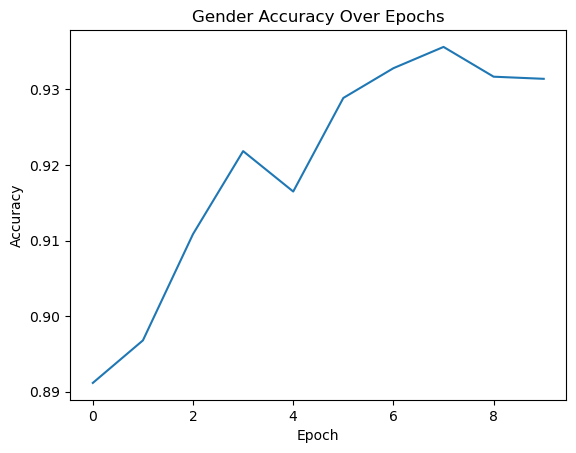

In [78]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history["val_age_mae"], label="Val Age MAE")
plt.title("Age MAE Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.show()

plt.figure()
plt.plot(history["val_gender_acc"], label="Val Gender Acc")
plt.title("Gender Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

We observe an elbow in loss at epoch 2 (quite early). Age MAE plateaus around 5, also relatively soon in the training. However, gender continues to improve as we train more epochs.

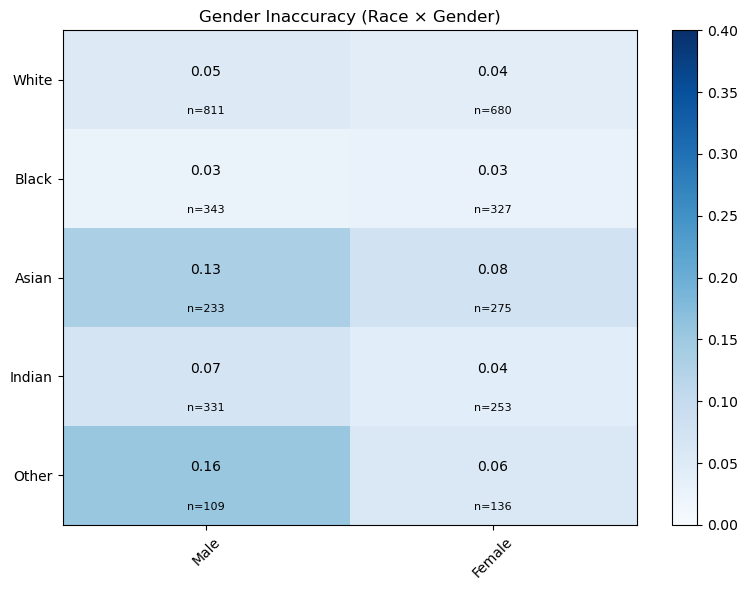

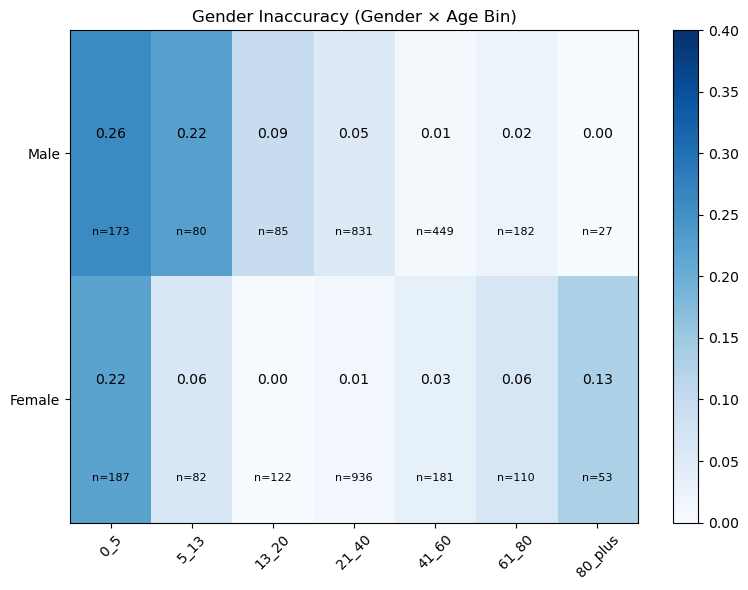

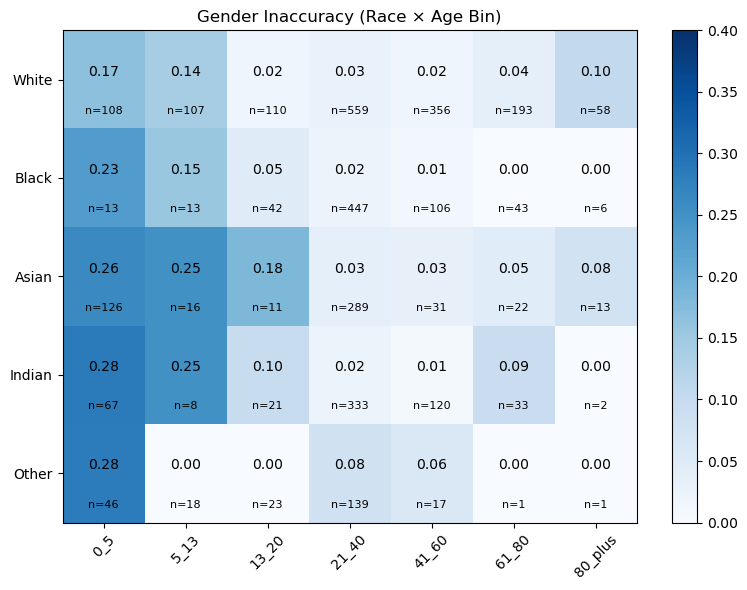

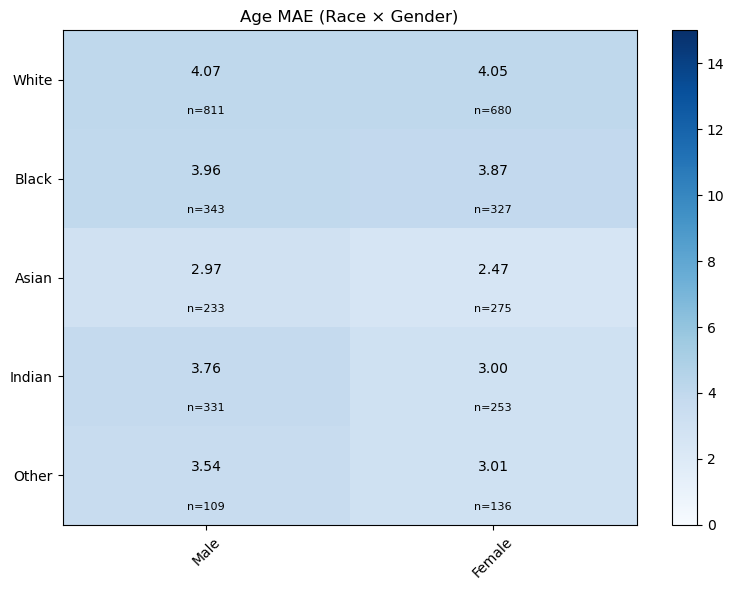

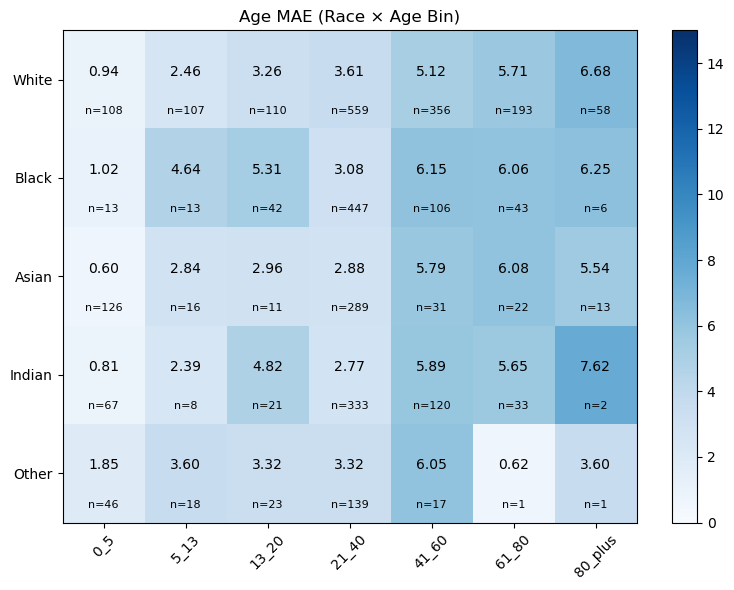

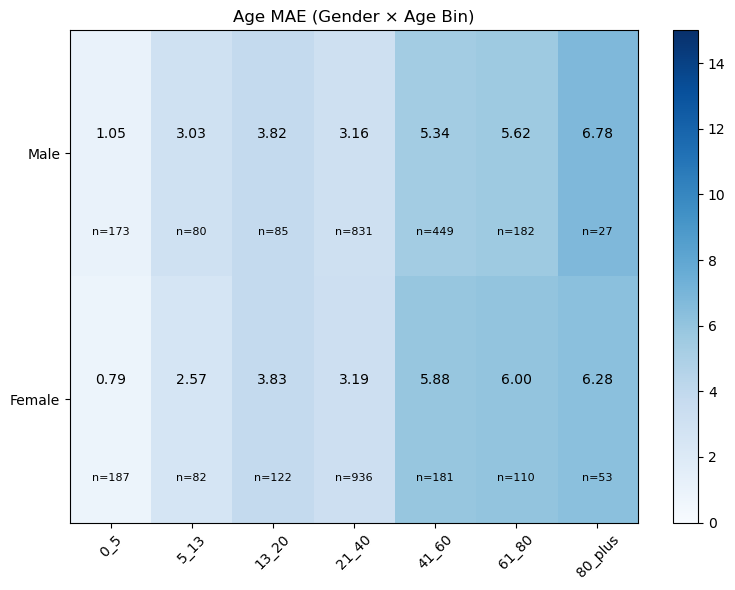

In [79]:
race_map = {
    "0": "White",
    "1": "Black",
    "2": "Asian",
    "3": "Indian",
    "4": "Other"
}

gender_map = {
    "0": "Male",
    "1": "Female"
}

age_order = ["0_5", "5_13", "13_20", "21_40", "41_60", "61_80", "80_plus"]
race_order = ["White", "Black", "Asian", "Indian", "Other"]
gender_order = ["Male", "Female"]


# =========================================================
# 1. GET TEST PREDICTIONS
# =========================================================

def get_test_predictions(model, loader, device):

    model.eval()
    results = []

    with torch.no_grad():

        for images, ages, genders, races, age_bins in loader:

            images = images.to(device)

            age_pred, gender_logit = model(images)

            gender_prob = torch.sigmoid(gender_logit)
            gender_pred = (gender_prob >= 0.5).float()

            for i in range(len(images)):

                g = str(int(genders[i].item()))
                r = str(races[i])

                results.append({

                    "true_age": ages[i].item(),
                    "pred_age": age_pred[i].item(),

                    "age_error":
                        age_pred[i].item() - ages[i].item(),

                    "true_gender":
                        gender_map[g],

                    "pred_gender":
                        gender_map[str(int(gender_pred[i].item()))],

                    "gender_correct":
                        int(
                            gender_pred[i].item()
                            == genders[i].item()
                        ),

                    "race":
                        race_map[r],

                    "age_bin":
                        str(age_bins[i])
                })

    return pd.DataFrame(results)


# =========================================================
# 2. GROUP METRICS
# =========================================================

def compute_group_metrics(df, group_cols):

    grouped = df.groupby(group_cols)

    out = {}

    for name, sub in grouped:

        out[name] = {

            "gender_acc":
                sub["gender_correct"].mean(),

            "age_mae":
                np.abs(sub["age_error"]).mean(),

            "count":
                len(sub)
        }

    return out


# =========================================================
# 3. BUILD VALUE + COUNT MATRICES
# =========================================================

def to_matrix(metric_dict, row_name, col_name, value_key):

    rows = []

    for k, v in metric_dict.items():

        if not isinstance(k, tuple):
            k = (k,)

        rows.append((
            *k,
            v[value_key],
            v["count"]
        ))

    df = pd.DataFrame(
        rows,
        columns=[row_name, col_name, "value", "count"]
    )

    value_matrix = df.pivot(
        index=row_name,
        columns=col_name,
        values="value"
    )

    count_matrix = df.pivot(
        index=row_name,
        columns=col_name,
        values="count"
    )

    return value_matrix, count_matrix


def reorder_matrix(matrix, row_order=None, col_order=None):

    if row_order is not None:
        matrix = matrix.reindex(row_order)

    if col_order is not None:
        matrix = matrix.reindex(columns=col_order)

    return matrix


# =========================================================
# 4. HEATMAP PLOTTING
# =========================================================

def plot_heatmap(
    matrix,
    counts,
    title,
    cmap="Blues",
    vmin=None,
    vmax=None
):

    plt.figure(figsize=(8, 6))

    if vmin is None:
        vmin = np.nanmin(matrix.values)

    if vmax is None:
        vmax = np.nanmax(matrix.values)

    im = plt.imshow(
        matrix,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    plt.title(title)

    plt.xticks(
        range(len(matrix.columns)),
        matrix.columns,
        rotation=45
    )

    plt.yticks(
        range(len(matrix.index)),
        matrix.index
    )


    # annotations of frequency
    for i in range(matrix.shape[0]):
    
        for j in range(matrix.shape[1]):
    
            val = matrix.iloc[i, j]
            cnt = counts.iloc[i, j]
    
            if not np.isnan(val):
    
                # main metric in center
                plt.text(
                    j,
                    i - 0.08,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="black"
                )
    
                # count near bottom
                plt.text(
                    j,
                    i + 0.32,
                    f"n={int(cnt)}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )

    plt.colorbar(im)

    plt.tight_layout()
    plt.show()


# =========================================================
# 5. TEST RESULTS
# =========================================================

test_results_baseline = get_test_predictions(
    resnet_model,
    test_loader,
    device
)


# =========================================================
# 6. GROUP INTERSECTIONS
# =========================================================

race_gender = compute_group_metrics(
    test_results_baseline,
    ["race", "true_gender"]
)

race_age = compute_group_metrics(
    test_results_baseline,
    ["race", "age_bin"]
)

gender_age = compute_group_metrics(
    test_results_baseline,
    ["true_gender", "age_bin"]
)


# =========================================================
# 7. BUILD MATRICES
# =========================================================

# ---------- Race × Gender ----------

rg_acc, rg_counts = to_matrix(
    race_gender,
    "race",
    "gender",
    "gender_acc"
)

rg_mae, _ = to_matrix(
    race_gender,
    "race",
    "gender",
    "age_mae"
)

# ---------- Race × Age ----------

ra_acc, ra_counts = to_matrix(
    race_age,
    "race",
    "age_bin",
    "gender_acc"
)

ra_mae, _ = to_matrix(
    race_age,
    "race",
    "age_bin",
    "age_mae"
)

# ---------- Gender × Age ----------

ga_acc, ga_counts = to_matrix(
    gender_age,
    "true_gender",
    "age_bin",
    "gender_acc"
)

ga_mae, _ = to_matrix(
    gender_age,
    "true_gender",
    "age_bin",
    "age_mae"
)


# =========================================================
# 8. INACCURACY MATRICES
# =========================================================

rg_inacc = 1 - rg_acc
ra_inacc = 1 - ra_acc
ga_inacc = 1 - ga_acc


# =========================================================
# 9. REORDER MATRICES
# =========================================================

rg_acc = reorder_matrix(
    rg_acc,
    race_order,
    gender_order
)

rg_mae = reorder_matrix(
    rg_mae,
    race_order,
    gender_order
)

rg_inacc = reorder_matrix(
    rg_inacc,
    race_order,
    gender_order
)

rg_counts = reorder_matrix(
    rg_counts,
    race_order,
    gender_order
)

ra_acc = reorder_matrix(
    ra_acc,
    race_order,
    age_order
)

ra_mae = reorder_matrix(
    ra_mae,
    race_order,
    age_order
)

ra_inacc = reorder_matrix(
    ra_inacc,
    race_order,
    age_order
)

ra_counts = reorder_matrix(
    ra_counts,
    race_order,
    age_order
)

ga_acc = reorder_matrix(
    ga_acc,
    gender_order,
    age_order
)

ga_mae = reorder_matrix(
    ga_mae,
    gender_order,
    age_order
)

ga_inacc = reorder_matrix(
    ga_inacc,
    gender_order,
    age_order
)

ga_counts = reorder_matrix(
    ga_counts,
    gender_order,
    age_order
)


# =========================================================
# 10. PLOTS
# =========================================================

INACC_VMIN, INACC_VMAX = 0.0, 0.4
MAE_VMIN, MAE_VMAX = 0.0, 15.0


# ---------- Gender Inaccuracy ----------

plot_heatmap(
    rg_inacc,
    rg_counts,
    "Gender Inaccuracy (Race × Gender)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)

plot_heatmap(
    ga_inacc,
    ga_counts,
    "Gender Inaccuracy (Gender × Age Bin)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)

plot_heatmap(
    ra_inacc,
    ra_counts,
    "Gender Inaccuracy (Race × Age Bin)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)


# ---------- Age MAE ----------

plot_heatmap(
    rg_mae,
    rg_counts,
    "Age MAE (Race × Gender)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

plot_heatmap(
    ra_mae,
    ra_counts,
    "Age MAE (Race × Age Bin)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

plot_heatmap(
    ga_mae,
    ga_counts,
    "Age MAE (Gender × Age Bin)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

Gender accuracy generally worse for asians and other, but especially poor for black labeled photos in the 80+ years old bin. The model also has a tough time predicting the genders of children aged 0-5, which makes sense as many people also struggle to tell the difference between genders of kids these ages. 

Older ages are generally harder for the model to accurately predict, this trend is clearly seen in the last figure. The other category intersected with 80+ years old has an especially high MAE.


### EDA with ResNet Embeddings

In [80]:
# embeddings
X = emb_outputs["embeddings"].numpy()

# labels
race = np.array(emb_outputs["race"])
gender = np.array(emb_outputs["gender"])
age_bin = np.array(emb_outputs["age_bin"])

#defines how umap will compress our embeddings
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(X)

race_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Other"
}

gender_map = {
    0.0: "Male",
    1.0: "Female"
}

def plot_umap(X_umap, labels, label_map=None, title=""):
    plt.figure(figsize=(7,6))

    labels = np.array(labels)
    try:
        labels = labels.astype(int)
    except:
        pass

    unique_labels = np.unique(labels)

    for lab in unique_labels:
        mask = labels == lab

        name = label_map[lab] if label_map else str(lab)

        plt.scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            label=name,
            alpha=0.6
        )

    plt.title(title)
    plt.legend()
    plt.show()

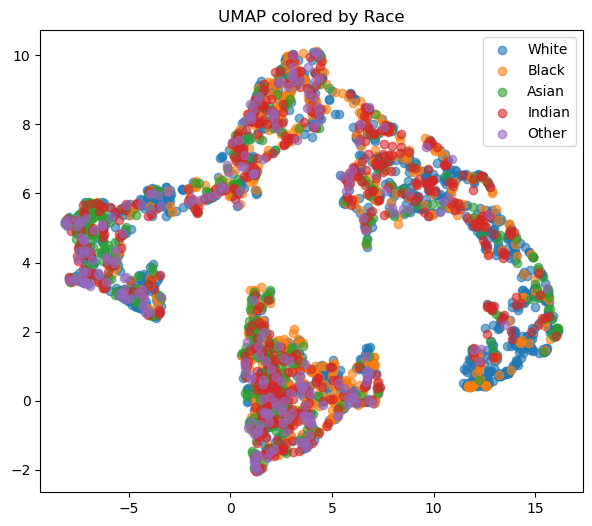

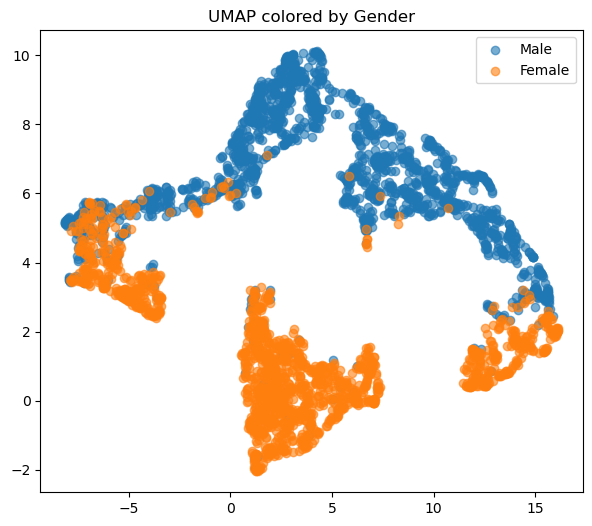

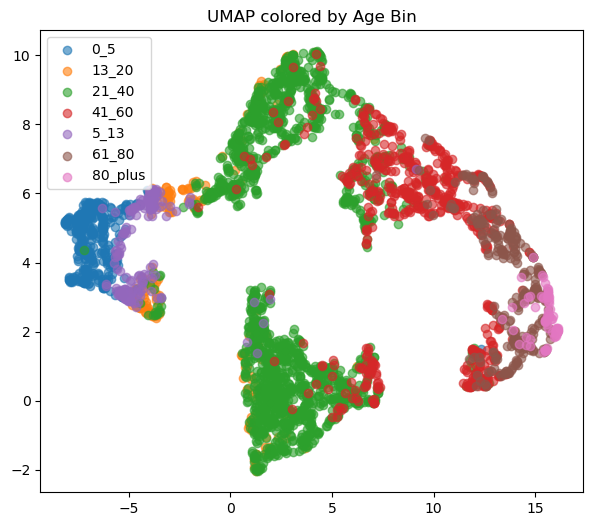

In [81]:
plot_umap(X_umap, race, race_map, "UMAP colored by Race")
plot_umap(X_umap, gender, gender_map, "UMAP colored by Gender")
plot_umap(X_umap, age_bin, None, "UMAP colored by Age Bin")

We see here that the embeddings generated by our ResNet model separate age and gender quite well. Since the model was not initally trained to predict race, it makes sense that the embeddings did not learn this feature. 

### Correction Strategy #1: Intersectional Reweighting of Disproportionately Small Groups

This reweighting method first groups each training sample by its intersection of race, gender, and age bin, then counts how frequently each group appears in the dataset. It assigns each sample a weight equal to the inverse of its group frequency, so rarer groups receive higher weights and common groups receive lower weights. The WeightedRandomSampler uses these weights to sample training examples with replacement, meaning minority groups are drawn more often within each epoch. As a result, the model sees a more balanced distribution of demographic subgroups during training, which should reduce bias toward overrepresented groups.

In [82]:
#UPSAMPLING RARE RACE AND GENDER COMBINATIONS
race = train_df["race"].astype(str).values
gender = train_df["gender"].astype(str).values
age_bin = train_df["eval_age_bin"].astype(str).values
groups = race + "_" + gender + "_" + age_bin

unique_groups, counts = np.unique(groups, return_counts=True)
group_freq = dict(zip(unique_groups, counts))

# weight = 1 / frequency
sample_weights = np.array([1.0 / group_freq[g] for g in groups])
sample_weights = sample_weights / sample_weights.sum() #normalize

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=g 
)

# dataloaders
train_dataset = UTKFaceDataset(train_df, transform=train_transform)
val_dataset = UTKFaceDataset(val_df, transform=val_transform)
test_dataset = UTKFaceDataset(test_df, transform=test_transform)

train_loader = DataLoader( #TRAIN LOADER CHANGED FOR UPSAMPLING
    train_dataset,
    batch_size=64,
    sampler=sampler,
    worker_init_fn=seed_worker,
    generator=g,
    num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

resnet_model = MultiTaskResNet().to(device)

age_criterion = nn.L1Loss()
gender_criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)

num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "val_age_mae": [],
    "val_gender_acc": []
}

best_val_mae = float("inf")
best_gender_acc = 0.0

CHECKPOINT_PATH = "resnet_reweighted_checkpoint.pt"
BEST_MODEL_PATH = "best_resnet_reweighted.pt"
# =========================
# LOAD CHECKPOINT IF EXISTS
# =========================
if os.path.exists(CHECKPOINT_PATH):
    print("Loading checkpoint...")

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    resnet_model.load_state_dict(checkpoint["model_state"])

    history = checkpoint["history"]
    best_val_mae = checkpoint.get("best_val_mae", float("inf"))
    best_gender_acc = checkpoint.get("best_gender_acc", 0.0)

    print("Loaded model + training history")

else:
    print("No checkpoint found. Training from scratch.")

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ---- train ----
        train_metrics = train_one_epoch(
            resnet_model, train_loader, optimizer,
            age_criterion, gender_criterion, device
        )

        # ---- validate ----
        val_metrics = evaluate(
            resnet_model, val_loader,
            age_criterion, gender_criterion, device
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_age_mae"].append(val_metrics["age_mae"])
        history["val_gender_acc"].append(val_metrics["gender_acc"])

        print(f"Train Loss: {train_metrics['loss']:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} | "
              f"Age MAE: {val_metrics['age_mae']:.2f} | "
              f"Gender Acc: {val_metrics['gender_acc']:.3f}")

        # ---- save best model ----
        if (val_metrics["age_mae"] < best_val_mae or
            (abs(val_metrics["age_mae"] - best_val_mae) < 1e-4 and
             val_metrics["gender_acc"] > best_gender_acc)):

            best_val_mae = val_metrics["age_mae"]
            best_gender_acc = val_metrics["gender_acc"]

            torch.save({
    "model_state": resnet_model.state_dict(),
    "history": history,
    "best_val_mae": best_val_mae,
    "best_gender_acc": best_gender_acc,
    "num_epochs": num_epochs,
    "seed": SEED
}, CHECKPOINT_PATH)

            print("Saved new best model")

    end_time = time.time()
    print(f"\nTraining time: {(end_time - start_time)/60:.2f} minutes")

Loading checkpoint...
Loaded model + training history


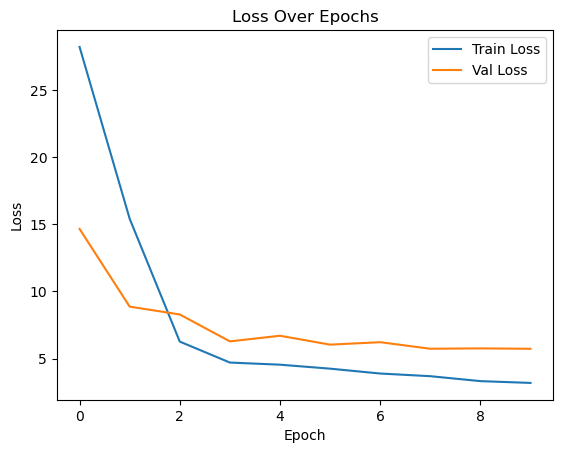

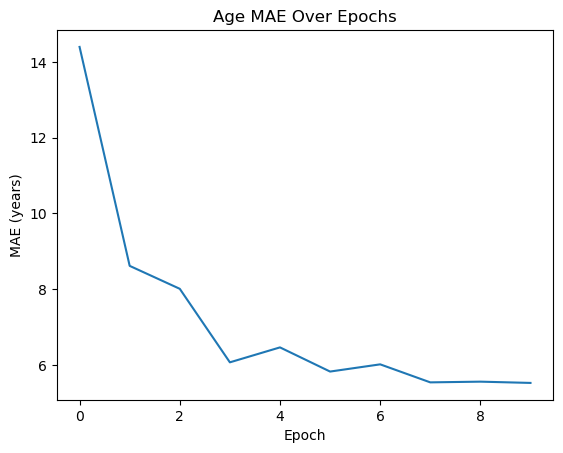

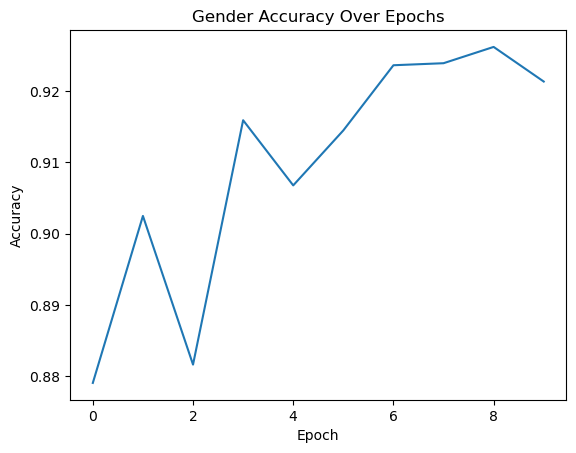

In [83]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history["val_age_mae"], label="Val Age MAE")
plt.title("Age MAE Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.show()

plt.figure()
plt.plot(history["val_gender_acc"], label="Val Gender Acc")
plt.title("Gender Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

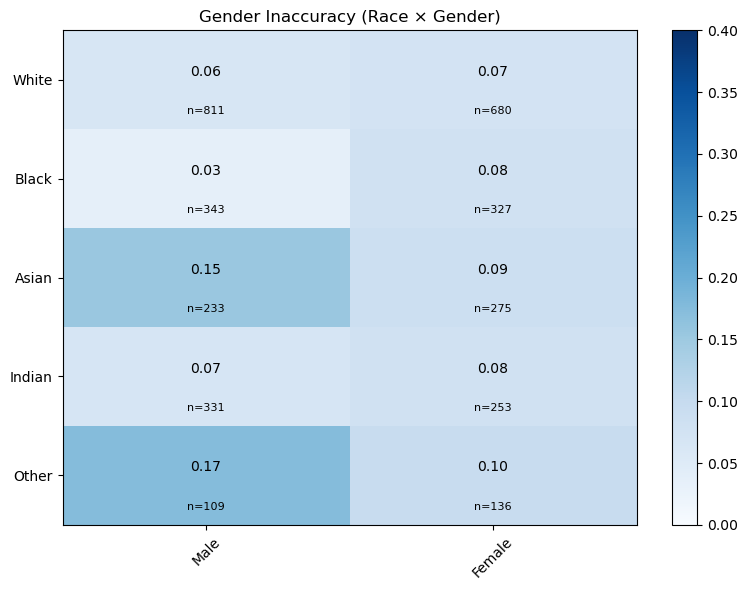

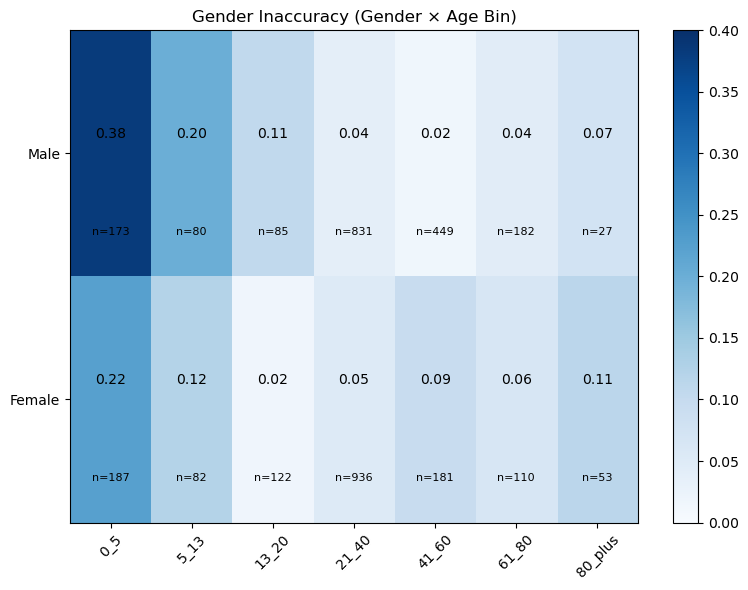

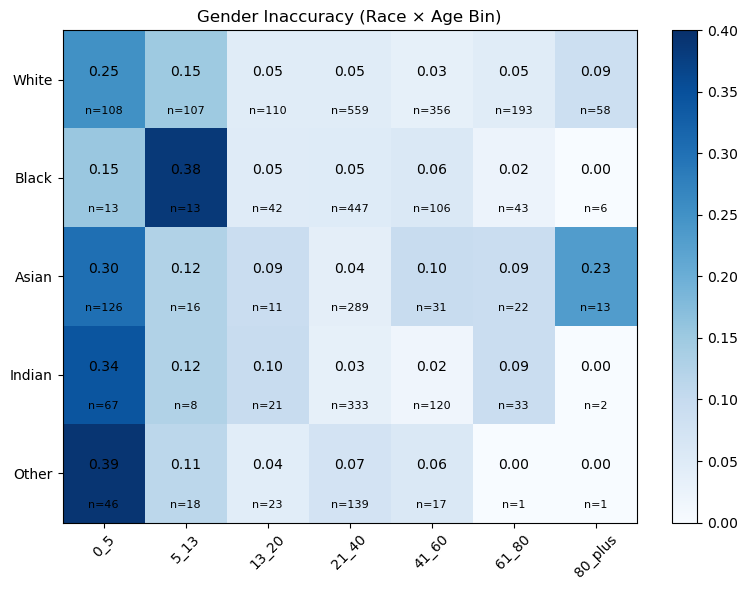

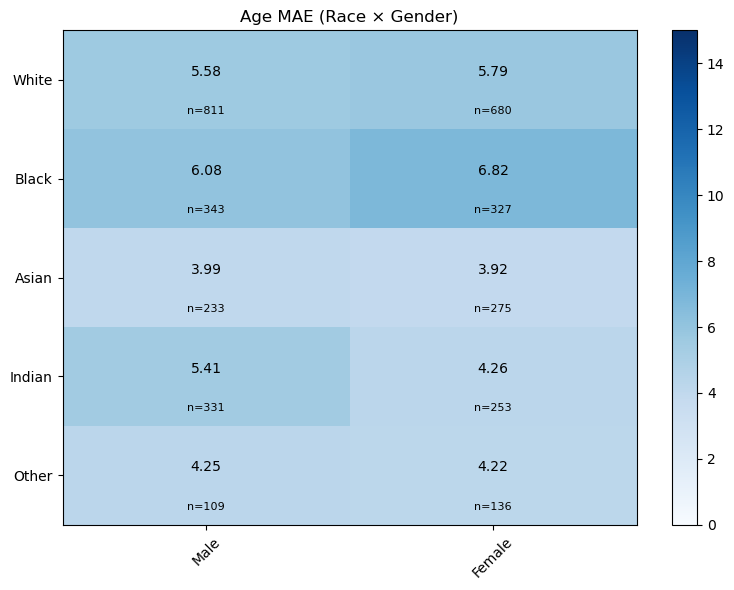

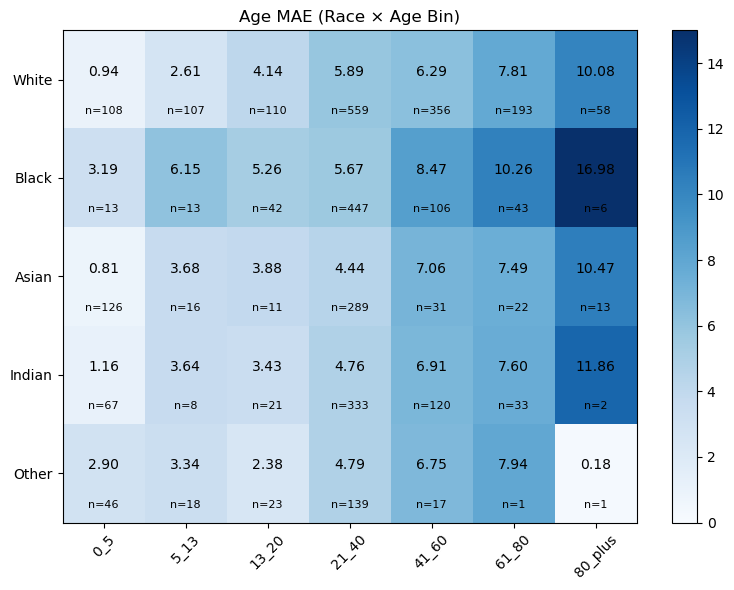

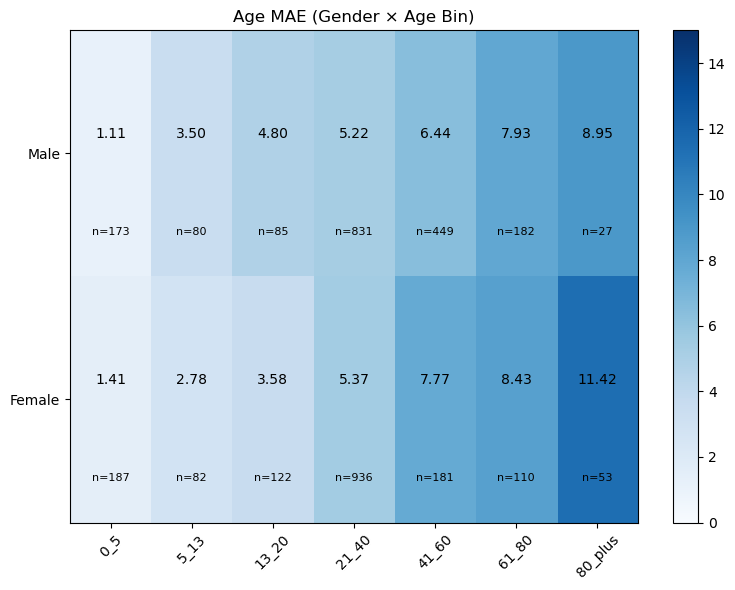

In [84]:
gender_map = {
    0: "Male",
    1: "Female"
}

race_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Other"
}


# =========================================================
# GET TEST PREDICTIONS
# =========================================================

def get_test_predictions(model, loader, device):

    model.eval()
    results = []

    with torch.no_grad():

        for images, ages, genders, races, age_bins in loader:

            images = images.to(device)

            age_pred, gender_logit = model(images)

            gender_prob = torch.sigmoid(gender_logit)
            gender_pred = (gender_prob >= 0.5).float()

            for i in range(len(images)):

                g = int(genders[i].item())
                p = int(gender_pred[i].item())

                r = int(
                    races[i].item()
                    if hasattr(races[i], "item")
                    else races[i]
                )

                results.append({

                    "true_age":
                        ages[i].item(),

                    "pred_age":
                        age_pred[i].item(),

                    "age_error":
                        age_pred[i].item() - ages[i].item(),

                    "true_gender":
                        gender_map[g],

                    "pred_gender":
                        gender_map[p],

                    "gender_correct":
                        int(p == g),

                    "race":
                        race_map[r],

                    "age_bin":
                        str(age_bins[i])
                })

    return pd.DataFrame(results)


# =========================================================
# TEST RESULTS
# =========================================================

test_results_reweighted = get_test_predictions(
    resnet_model,
    test_loader,
    device
)


# =========================================================
# COMPUTE GROUP METRICS
# =========================================================

def compute_group_metrics(df, group_cols):

    grouped = df.groupby(group_cols)

    out = {}

    for name, sub in grouped:

        out[name] = {

            "gender_acc":
                sub["gender_correct"].mean(),

            "age_mae":
                np.abs(sub["age_error"]).mean(),

            "count":
                len(sub)
        }

    return out

# =========================================================
# REORDER MATRICES
# =========================================================

def reorder_matrix(matrix, row_order=None, col_order=None):

    if row_order is not None:
        matrix = matrix.reindex(row_order)

    if col_order is not None:
        matrix = matrix.reindex(columns=col_order)

    return matrix


# =========================================================
# HEATMAP PLOTTING
# =========================================================

def plot_heatmap(
    matrix,
    counts,
    title,
    cmap="Blues",
    vmin=None,
    vmax=None
):

    plt.figure(figsize=(8, 6))

    if vmin is None:
        vmin = np.nanmin(matrix.values)

    if vmax is None:
        vmax = np.nanmax(matrix.values)

    im = plt.imshow(
        matrix,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    plt.title(title)

    plt.xticks(
        range(len(matrix.columns)),
        matrix.columns,
        rotation=45
    )

    plt.yticks(
        range(len(matrix.index)),
        matrix.index
    )

    # annotations
    for i in range(matrix.shape[0]):

        for j in range(matrix.shape[1]):

            val = matrix.iloc[i, j]
            cnt = counts.iloc[i, j]

            if not np.isnan(val):

                # main metric
                plt.text(
                    j,
                    i - 0.08,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="black"
                )

                # frequency count near bottom
                plt.text(
                    j,
                    i + 0.32,
                    f"n={int(cnt)}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )

    plt.colorbar(im)

    plt.tight_layout()
    plt.show()


# =========================================================
# COMPUTE INTERSECTIONAL GROUPS
# =========================================================

race_gender = compute_group_metrics(
    test_results_reweighted,
    ["race", "true_gender"]
)

race_age = compute_group_metrics(
    test_results_reweighted,
    ["race", "age_bin"]
)

gender_age = compute_group_metrics(
    test_results_reweighted,
    ["true_gender", "age_bin"]
)


# =========================================================
# BUILD MATRICES
# =========================================================

# ---------- Race × Gender ----------

rg_acc, rg_counts = to_matrix(
    race_gender,
    "race",
    "gender",
    "gender_acc"
)

rg_mae, _ = to_matrix(
    race_gender,
    "race",
    "gender",
    "age_mae"
)

# ---------- Race × Age ----------

ra_acc, ra_counts = to_matrix(
    race_age,
    "race",
    "age_bin",
    "gender_acc"
)

ra_mae, _ = to_matrix(
    race_age,
    "race",
    "age_bin",
    "age_mae"
)

# ---------- Gender × Age ----------

ga_acc, ga_counts = to_matrix(
    gender_age,
    "true_gender",
    "age_bin",
    "gender_acc"
)

ga_mae, _ = to_matrix(
    gender_age,
    "true_gender",
    "age_bin",
    "age_mae"
)


# =========================================================
# INACCURACY MATRICES
# =========================================================

rg_inacc = 1 - rg_acc
ra_inacc = 1 - ra_acc
ga_inacc = 1 - ga_acc


# =========================================================
# REORDER MATRICES
# =========================================================

rg_acc = reorder_matrix(rg_acc, race_order, gender_order)
rg_mae = reorder_matrix(rg_mae, race_order, gender_order)
rg_inacc = reorder_matrix(rg_inacc, race_order, gender_order)
rg_counts = reorder_matrix(rg_counts, race_order, gender_order)

ra_acc = reorder_matrix(ra_acc, race_order, age_order)
ra_mae = reorder_matrix(ra_mae, race_order, age_order)
ra_inacc = reorder_matrix(ra_inacc, race_order, age_order)
ra_counts = reorder_matrix(ra_counts, race_order, age_order)

ga_acc = reorder_matrix(ga_acc, gender_order, age_order)
ga_mae = reorder_matrix(ga_mae, gender_order, age_order)
ga_inacc = reorder_matrix(ga_inacc, gender_order, age_order)
ga_counts = reorder_matrix(ga_counts, gender_order, age_order)


# =========================================================
# PLOTS
# =========================================================

INACC_VMIN, INACC_VMAX = 0.0, 0.4
MAE_VMIN, MAE_VMAX = 0.0, 15.0


# ---------- Gender Inaccuracy ----------

plot_heatmap(
    rg_inacc,
    rg_counts,
    "Gender Inaccuracy (Race × Gender)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)

plot_heatmap(
    ga_inacc,
    ga_counts,
    "Gender Inaccuracy (Gender × Age Bin)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)

plot_heatmap(
    ra_inacc,
    ra_counts,
    "Gender Inaccuracy (Race × Age Bin)",
    vmin=INACC_VMIN,
    vmax=INACC_VMAX
)


# ---------- Age MAE ----------

plot_heatmap(
    rg_mae,
    rg_counts,
    "Age MAE (Race × Gender)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

plot_heatmap(
    ra_mae,
    ra_counts,
    "Age MAE (Race × Age Bin)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

plot_heatmap(
    ga_mae,
    ga_counts,
    "Age MAE (Gender × Age Bin)",
    vmin=MAE_VMIN,
    vmax=MAE_VMAX
)

The reweighting appears to have slightly helped with bias, smoothing out the heat map and reducing error/inaccuracy of the worst groups by a little bit.

### Correction Strategy #2: Thresholding

In order to implement some of the correction methods we ideated, we need to be able to adjust the model's thresholding by race. To do that, we must allow the model to access the racial information of each image, which we didn't do in our first pass model. Here, we use the same ResNet18 model but add a new classifier head that predicts race (this is working under the assumption that when models are fed images, they are not explicitly told the race of the person in the image). This way, we can optimize race prediction in a supervised manner, which in turn trains the model's ability to make an informed decision about which gender/age prediction threshold to use in the final classification layer.

Define and train the 3-head model.

In [85]:
labels = ["0_5",      # infants / toddlers
          "5_13",     # children
          "13_20",    # teens
          "21_40",
          "41_60",
          "61_80",
          "80_plus"
]

df["eval_age_bin"] = pd.cut(
    df["age"],
    bins=[0, 5, 13, 20, 40, 60, 80, 120],
    labels=["0_5", "5_13", "13_20", "21_40", "41_60", "61_80", "80_plus"],
    include_lowest=True
)

race_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Other"
}

gender_map = {
    0: "Male",
    1: "Female"
}

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = row["image"]

        if self.transform:
            image = self.transform(image)

        age = torch.tensor(row["age"], dtype=torch.float32)
        gender = torch.tensor(row["gender"], dtype=torch.float32)

        race = torch.tensor(row["race"], dtype=torch.long) 
        age_bin = str(row["eval_age_bin"])

        return image, age, gender, race, age_bin


df["stratify_key"] = (
    df["race"].astype(str) + "_" +
    df["gender"].astype(str)
)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
    stratify=df["stratify_key"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
    stratify=temp_df["stratify_key"]
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")


train_dataset = UTKFaceDataset(train_df, transform=train_transform)
val_dataset = UTKFaceDataset(val_df, transform=val_transform)
test_dataset = UTKFaceDataset(test_df, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g
)

Train size: 16320
Validation size: 3497
Test size: 3498


In [86]:
class MultiTaskResNet(nn.Module):
    def __init__(self, num_races=5):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.age_head = nn.Linear(in_features, 1)      
        self.gender_head = nn.Linear(in_features, 1)    
        self.race_head = nn.Linear(in_features, num_races)     

    def forward(self, x):
        features = self.backbone(x)

        age_pred = self.age_head(features).squeeze(1)
        gender_logit = self.gender_head(features).squeeze(1)
        race_logits = self.race_head(features)

        return age_pred, gender_logit, race_logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_model = MultiTaskResNet(num_races=5).to(device)

age_criterion = nn.L1Loss()
gender_criterion = nn.BCEWithLogitsLoss()
race_criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)


def train_one_epoch(model, loader, optimizer,
                    age_criterion, gender_criterion, race_criterion,
                    device):

    model.train()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0
    total_race_loss = 0.0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, ages, genders, races, _ in loop:
        images = images.to(device)
        ages = ages.to(device)
        genders = genders.to(device)
        races = races.to(device)

        optimizer.zero_grad()

        age_pred, gender_logit, race_logits = model(images)

        age_loss = age_criterion(age_pred, ages)
        gender_loss = gender_criterion(gender_logit, genders)
        race_loss = race_criterion(race_logits, races)

        loss = age_loss + gender_loss + race_loss
        loss.backward()
        optimizer.step()

        bs = images.size(0)

        total_loss += loss.item() * bs
        total_age_loss += age_loss.item() * bs
        total_gender_loss += gender_loss.item() * bs
        total_race_loss += race_loss.item() * bs

        loop.set_postfix(loss=loss.item())

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n,
        "race_loss": total_race_loss / n
    }


def evaluate(model, loader,
             age_criterion, gender_criterion, race_criterion,
             device):

    model.eval()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0
    total_race_loss = 0.0

    all_age_preds, all_ages = [], []
    all_gender_preds, all_genders = [], []
    all_race_preds, all_races = [], []

    loop = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for images, ages, genders, races, _ in loop:

            images = images.to(device)
            ages = ages.to(device)
            genders = genders.to(device)
            races = races.to(device)

            age_pred, gender_logit, race_logits = model(images)

            age_loss = age_criterion(age_pred, ages)
            gender_loss = gender_criterion(gender_logit, genders)
            race_loss = race_criterion(race_logits, races)

            loss = age_loss + gender_loss + race_loss

            bs = images.size(0)

            total_loss += loss.item() * bs
            total_age_loss += age_loss.item() * bs
            total_gender_loss += gender_loss.item() * bs
            total_race_loss += race_loss.item() * bs

            gender_preds = (torch.sigmoid(gender_logit) >= 0.5).float()
            race_preds = torch.argmax(race_logits, dim=1)

            all_age_preds.append(age_pred.cpu())
            all_ages.append(ages.cpu())

            all_gender_preds.append(gender_preds.cpu())
            all_genders.append(genders.cpu())

            all_race_preds.append(race_preds.cpu())
            all_races.append(races.cpu())

    all_age_preds = torch.cat(all_age_preds)
    all_ages = torch.cat(all_ages)
    all_gender_preds = torch.cat(all_gender_preds)
    all_genders = torch.cat(all_genders)
    all_race_preds = torch.cat(all_race_preds)
    all_races = torch.cat(all_races)

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n,
        "race_loss": total_race_loss / n,
        "age_mae": torch.mean(torch.abs(all_age_preds - all_ages)).item(),
        "gender_acc": (all_gender_preds == all_genders).float().mean().item(),
        "race_acc": (all_race_preds == all_races).float().mean().item()
    }

In [87]:
CHECKPOINT_PATH = "resnet_3head_checkpoint.pt"
BEST_PATH = "best_resnet_3head.pt"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_age_mae": [],
    "val_gender_acc": [],
    "val_race_acc": []
}

best_val_mae = float("inf")
best_gender_acc = 0.0

# =========================================================
# LOAD AND EXIT IF MODEL ALREADY EXISTS
# =========================================================
if os.path.exists(CHECKPOINT_PATH):

    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

    resnet_model.load_state_dict(ckpt["model_state_dict"])

    history = ckpt.get("history", history)
    best_val_mae = ckpt.get("best_val_mae", best_val_mae)
    best_gender_acc = ckpt.get("best_gender_acc", best_gender_acc)

    print("Model loaded successfully. Training skipped.")

    # STOP HERE 
    trained_model_ready = True

else:
    print("No checkpoint found — starting training.")

    trained_model_ready = False

if not trained_model_ready:

    num_epochs = 10

    for epoch in range(num_epochs):

        print(f"\nEpoch {epoch+1}/{num_epochs}")

        train_metrics = train_one_epoch(
            resnet_model, train_loader, optimizer,
            age_criterion, gender_criterion, race_criterion, device
        )

        val_metrics = evaluate(
            resnet_model, val_loader,
            age_criterion, gender_criterion, race_criterion, device
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_age_mae"].append(val_metrics["age_mae"])
        history["val_gender_acc"].append(val_metrics["gender_acc"])
        history["val_race_acc"].append(val_metrics["race_acc"])

        print(
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Age MAE: {val_metrics['age_mae']:.2f} | "
            f"Gender Acc: {val_metrics['gender_acc']:.3f} | "
            f"Race Acc: {val_metrics['race_acc']:.3f}"
        )

        # save checkpoint every epoch
        torch.save({
            "model_state_dict": resnet_model.state_dict(),
            "history": history,
            "best_val_mae": best_val_mae,
            "best_gender_acc": best_gender_acc,
            "epoch": epoch
        }, CHECKPOINT_PATH)

        print("Checkpoint saved")

else:
    print("Skipping training — model already trained.")

Model loaded successfully. Training skipped.
Skipping training — model already trained.


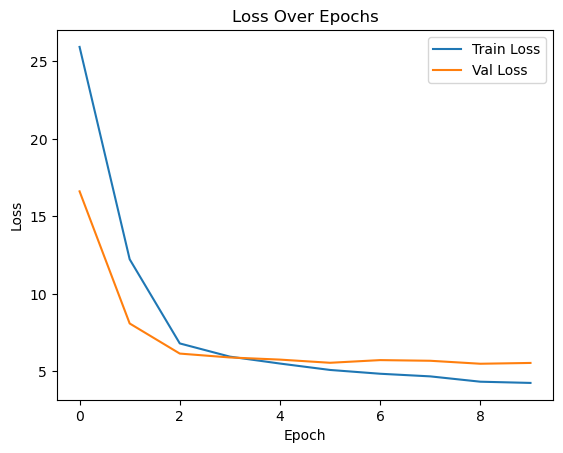

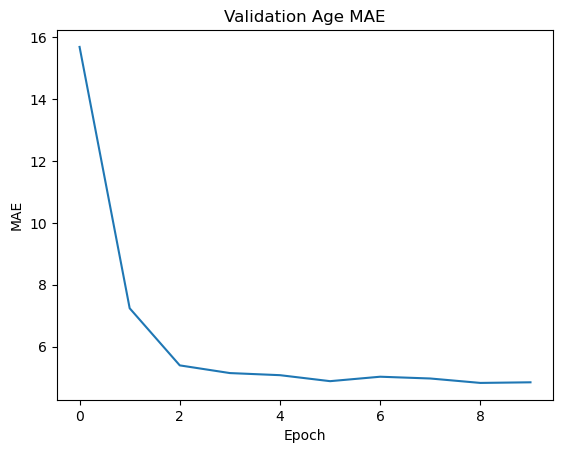

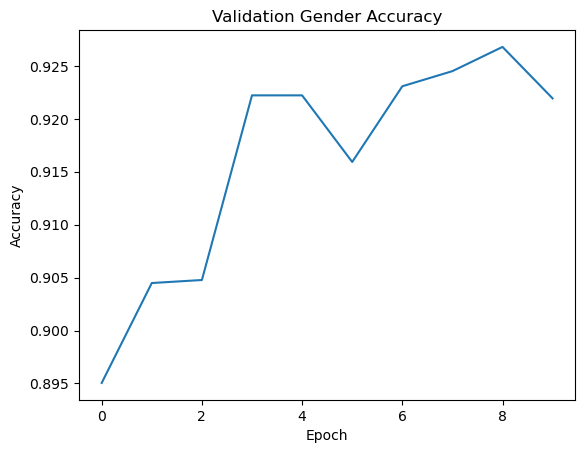

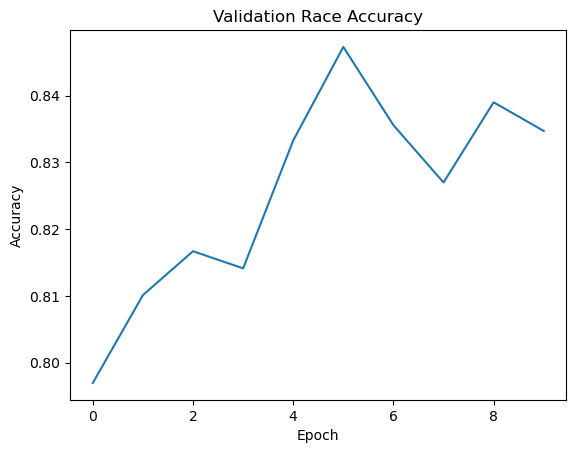

In [88]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history["val_age_mae"])
plt.title("Validation Age MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.show()

plt.figure()
plt.plot(history["val_gender_acc"])
plt.title("Validation Gender Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(history["val_race_acc"])
plt.title("Validation Race Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## Thresholding

Load 3 Head Trained Model

In [89]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_model = MultiTaskResNet(num_races=5).to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
resnet_model.load_state_dict(checkpoint["model_state_dict"])
# resnet_model.eval()

<All keys matched successfully>

Adjust the thresholds of the 3 head model

In [90]:
def get_predictions_for_thresholding(model, loader, device):
    model.eval()
    results = []

    with torch.no_grad():
        for images, ages, genders, races, age_bins in loader:
            images = images.to(device)

            age_pred, gender_logit, race_logits = model(images)

            gender_prob = torch.sigmoid(gender_logit)
            gender_pred = (gender_prob >= 0.5).float()
            pred_race = torch.argmax(race_logits, dim=1)

            for i in range(len(images)):
                true_gender_num = int(genders[i].item())
                pred_gender_num = int(gender_pred[i].item())

                true_race_num = int(races[i].item())
                pred_race_num = int(pred_race[i].item())

                results.append({
                    "true_age": float(ages[i].item()),
                    "pred_age": float(age_pred[i].item()),
                    "age_error": float(age_pred[i].item() - ages[i].item()),
                    
                    "true_gender_num": true_gender_num,  # number
                    "pred_gender_num": pred_gender_num,
                    "true_gender": gender_map[true_gender_num],   # string
                    "pred_gender": gender_map[pred_gender_num],
                    "gender_prob": float(gender_prob[i].item()),
                    "gender_correct": int(pred_gender_num == true_gender_num),

                    "true_race_num": true_race_num,
                    "pred_race_num": pred_race_num,
                    "true_race": race_map[true_race_num],
                    "pred_race": race_map[pred_race_num],

                    "age_bin": str(age_bins[i])
                })

    return pd.DataFrame(results)

def choose_thresholds_by_predicted_race(val_results, min_count=20, max_dev=0.25):
    low = 0.5 - max_dev
    high = 0.5 + max_dev
    threshold_grid = np.linspace(low, high, 61)

    thresholds = {}

    for race_id in sorted(val_results["pred_race_num"].unique()):
        subset = val_results[val_results["pred_race_num"] == race_id].copy()

        if len(subset) < min_count:
            thresholds[race_id] = 0.5
            continue

        best_threshold = 0.5
        best_acc = -1.0

        for t in threshold_grid:
            preds = (subset["gender_prob"] >= t).astype(int)
            acc = (preds == subset["true_gender_num"]).mean()

            if acc > best_acc:
                best_acc = acc
                best_threshold = float(t)

        thresholds[race_id] = best_threshold

    return thresholds

def apply_race_specific_gender_thresholds(results_df, thresholds):
    out = results_df.copy()

    out["gender_threshold"] = out["pred_race_num"].map(thresholds).fillna(0.5)

    out["pred_gender_adjusted"] = (
        out["gender_prob"] >= out["gender_threshold"]
    ).astype(int)

    out["gender_correct_adjusted"] = (
        out["pred_gender_adjusted"] == out["true_gender_num"]
    ).astype(int)

    return out

In [91]:
val_results = get_predictions_for_thresholding(resnet_model, val_loader, device)
thresholds = choose_thresholds_by_predicted_race(val_results)

print("Thresholds:", thresholds)

test_results_default = get_predictions_for_thresholding(resnet_model, test_loader, device)
test_results_adjusted = apply_race_specific_gender_thresholds(
    test_results_default.copy(),
    thresholds
)

Thresholds: {0: 0.35833333333333334, 1: 0.5083333333333333, 2: 0.5333333333333333, 3: 0.4, 4: 0.3833333333333333}


Compare default and thresholded models.

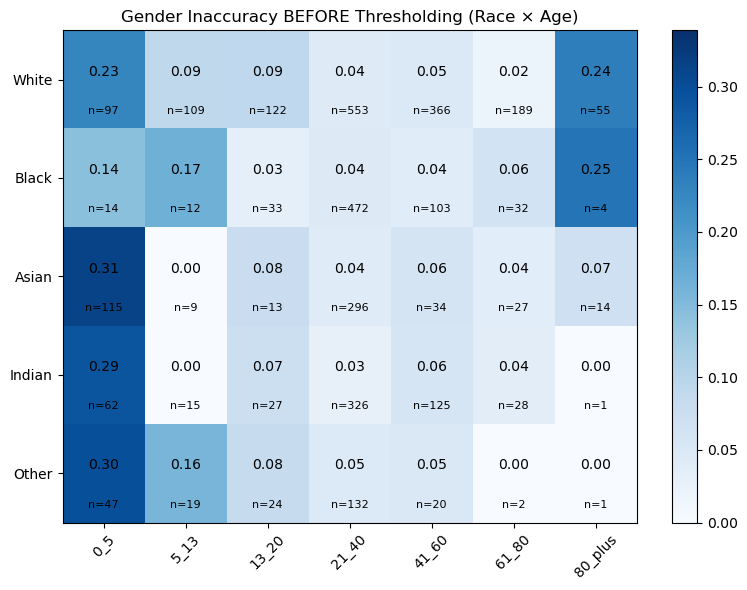

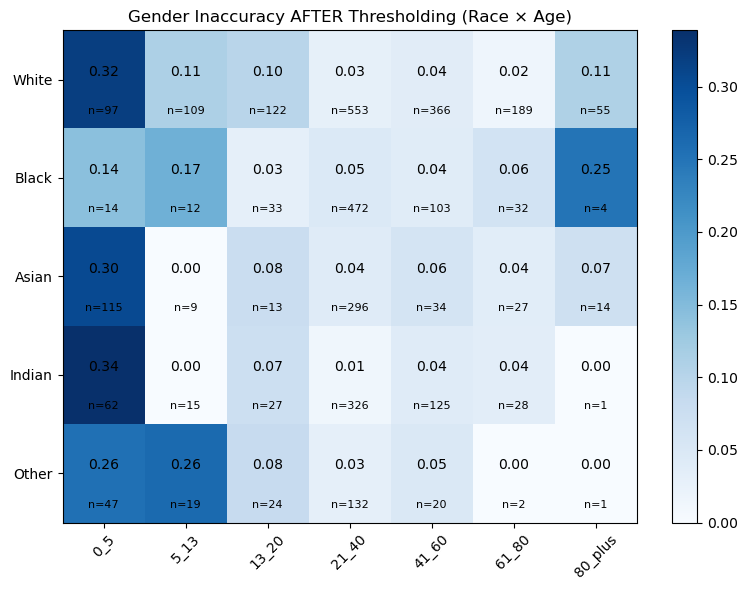

In [92]:
age_order = ["0_5", "5_13", "13_20", "21_40", "41_60", "61_80", "80_plus"]
race_order = ["White", "Black", "Asian", "Indian", "Other"]
gender_order = ["Male", "Female"]


# =========================================================
# GROUP METRICS
# =========================================================

def compute_heatmap_group_metrics(df, group_cols, gender_correct_col):

    grouped = df.groupby(group_cols)
    out = {}

    for name, sub in grouped:

        out[name] = {

            "gender_acc":
                sub[gender_correct_col].mean(),

            "age_mae":
                np.abs(sub["age_error"]).mean(),

            "count":
                len(sub)
        }

    return out


# =========================================================
# REORDER
# =========================================================

def reorder_matrix(matrix, row_order=None, col_order=None):

    if row_order is not None:
        matrix = matrix.reindex(row_order)

    if col_order is not None:
        matrix = matrix.reindex(columns=col_order)

    return matrix


# =========================================================
# HEATMAP
# =========================================================

def plot_heatmap(matrix, counts, title,
                 cmap="Blues",
                 fmt=".2f",
                 vmin=None,
                 vmax=None):

    plt.figure(figsize=(8, 6))

    if vmin is None:
        vmin = np.nanmin(matrix.values)

    if vmax is None:
        vmax = np.nanmax(matrix.values)

    im = plt.imshow(
        matrix,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    plt.title(title)
    plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=45)
    plt.yticks(range(len(matrix.index)), matrix.index)

    # annotations
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):

            val = matrix.iloc[i, j]
            cnt = counts.iloc[i, j]

            if not np.isnan(val):

                # metric (top/center)
                plt.text(
                    j, i - 0.08,
                    format(val, fmt),
                    ha="center",
                    va="center",
                    fontsize=10
                )

                # count (bottom)
                plt.text(
                    j, i + 0.32,
                    f"n={int(cnt)}",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()


# =========================================================
# DEFAULT THRESHOLD
# =========================================================

race_age_default = compute_heatmap_group_metrics(
    test_results_default,
    ["true_race", "age_bin"],
    gender_correct_col="gender_correct"
)

ra_acc_default, ra_counts_default = to_matrix(
    race_age_default,
    "race",
    "age_bin",
    "gender_acc"
)

ra_mae_default, _ = to_matrix(
    race_age_default,
    "race",
    "age_bin",
    "age_mae"
)

ra_inacc_default = 1 - ra_acc_default


ra_acc_default = reorder_matrix(ra_acc_default, race_order, age_order)
ra_mae_default = reorder_matrix(ra_mae_default, race_order, age_order)
ra_inacc_default = reorder_matrix(ra_inacc_default, race_order, age_order)
ra_counts_default = reorder_matrix(ra_counts_default, race_order, age_order)


# =========================================================
# ADJUSTED THRESHOLD
# =========================================================

race_age_adjusted = compute_heatmap_group_metrics(
    test_results_adjusted,
    ["true_race", "age_bin"],
    gender_correct_col="gender_correct_adjusted"
)

ra_acc_adjusted, ra_counts_adjusted = to_matrix(
    race_age_adjusted,
    "race",
    "age_bin",
    "gender_acc"
)

ra_mae_adjusted, _ = to_matrix(
    race_age_adjusted,
    "race",
    "age_bin",
    "age_mae"
)

ra_inacc_adjusted = 1 - ra_acc_adjusted


ra_acc_adjusted = reorder_matrix(ra_acc_adjusted, race_order, age_order)
ra_mae_adjusted = reorder_matrix(ra_mae_adjusted, race_order, age_order)
ra_inacc_adjusted = reorder_matrix(ra_inacc_adjusted, race_order, age_order)
ra_counts_adjusted = reorder_matrix(ra_counts_adjusted, race_order, age_order)


# =========================================================
# GLOBAL COLOR SCALE
# =========================================================

vmin = min(
    ra_inacc_default.min().min(),
    ra_inacc_adjusted.min().min()
)

vmax = max(
    ra_inacc_default.max().max(),
    ra_inacc_adjusted.max().max()
)


# =========================================================
# PLOTS
# =========================================================

plot_heatmap(
    ra_inacc_default,
    ra_counts_default,
    "Gender Inaccuracy BEFORE Thresholding (Race × Age)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

plot_heatmap(
    ra_inacc_adjusted,
    ra_counts_adjusted,
    "Gender Inaccuracy AFTER Thresholding (Race × Age)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

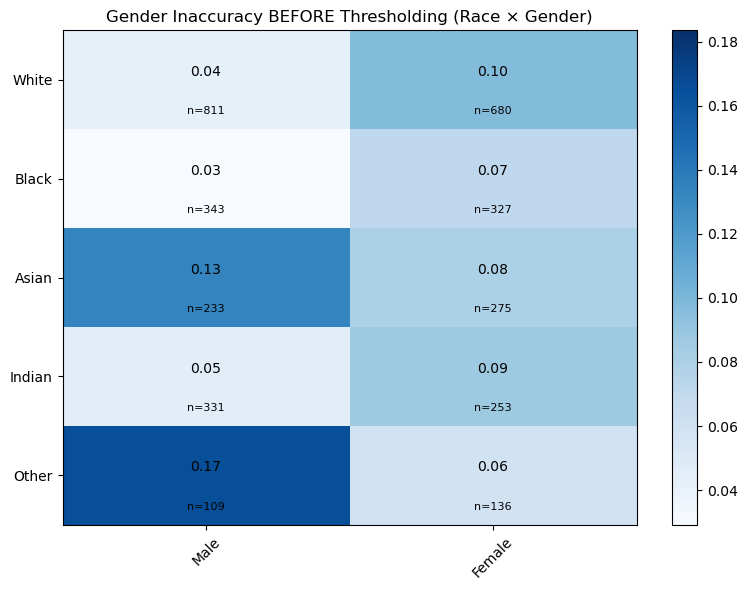

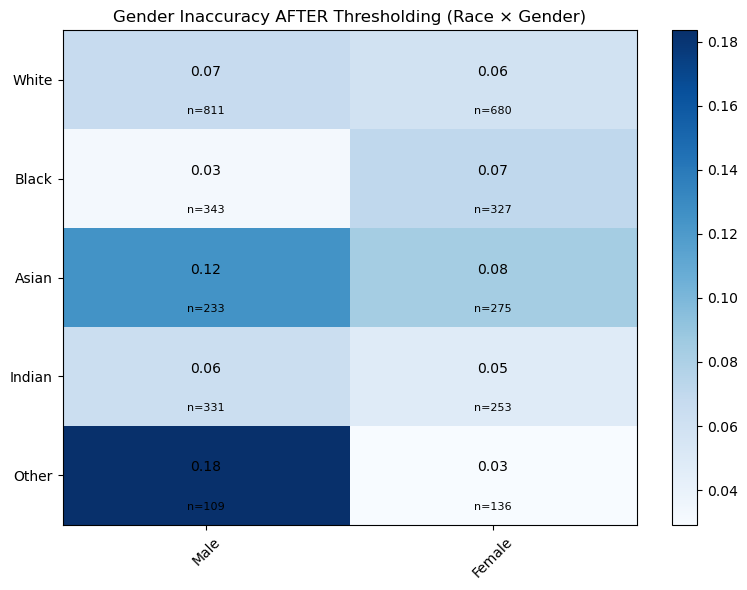

In [93]:
# =========================================================
# DEFAULT
# =========================================================

race_gender_default = compute_heatmap_group_metrics(
    test_results_default,
    ["true_race", "true_gender"],
    gender_correct_col="gender_correct"
)

rg_acc_default, rg_counts_default = to_matrix(
    race_gender_default,
    "race",
    "gender",
    "gender_acc"
)

rg_mae_default, _ = to_matrix(
    race_gender_default,
    "race",
    "gender",
    "age_mae"
)

rg_inacc_default = 1 - rg_acc_default


rg_acc_default = reorder_matrix(rg_acc_default, race_order, gender_order)
rg_mae_default = reorder_matrix(rg_mae_default, race_order, gender_order)
rg_inacc_default = reorder_matrix(rg_inacc_default, race_order, gender_order)
rg_counts_default = reorder_matrix(rg_counts_default, race_order, gender_order)


# =========================================================
# ADJUSTED
# =========================================================

race_gender_adjusted = compute_heatmap_group_metrics(
    test_results_adjusted,
    ["true_race", "true_gender"],
    gender_correct_col="gender_correct_adjusted"
)

rg_acc_adjusted, rg_counts_adjusted = to_matrix(
    race_gender_adjusted,
    "race",
    "gender",
    "gender_acc"
)

rg_mae_adjusted, _ = to_matrix(
    race_gender_adjusted,
    "race",
    "gender",
    "age_mae"
)

rg_inacc_adjusted = 1 - rg_acc_adjusted


rg_acc_adjusted = reorder_matrix(rg_acc_adjusted, race_order, gender_order)
rg_mae_adjusted = reorder_matrix(rg_mae_adjusted, race_order, gender_order)
rg_inacc_adjusted = reorder_matrix(rg_inacc_adjusted, race_order, gender_order)
rg_counts_adjusted = reorder_matrix(rg_counts_adjusted, race_order, gender_order)


# =========================================================
# PLOT RANGE (FIXED TYPO)
# =========================================================

vmin = min(
    rg_inacc_default.min().min(),
    rg_inacc_adjusted.min().min()
)

vmax = max(
    rg_inacc_default.max().max(),
    rg_inacc_adjusted.max().max()
)


# =========================================================
# PLOTS
# =========================================================

plot_heatmap(
    rg_inacc_default,
    rg_counts_default,
    "Gender Inaccuracy BEFORE Thresholding (Race × Gender)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

plot_heatmap(
    rg_inacc_adjusted,
    rg_counts_adjusted,
    "Gender Inaccuracy AFTER Thresholding (Race × Gender)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

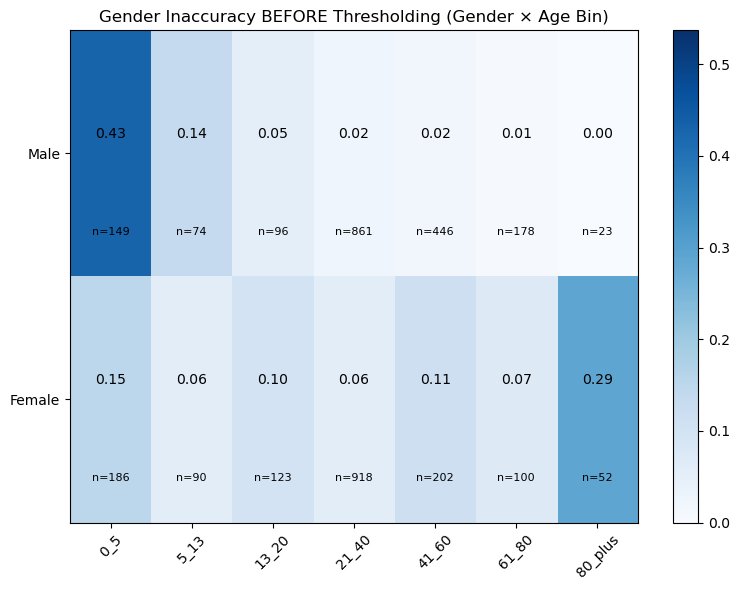

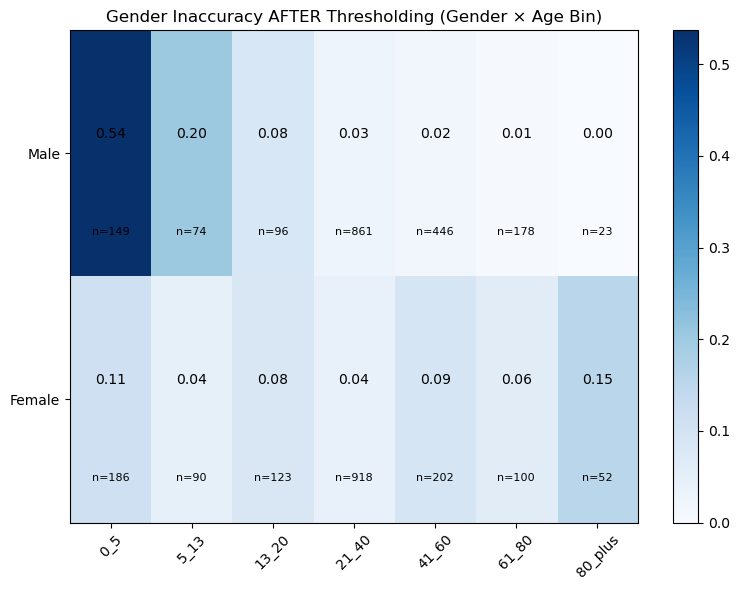

In [94]:
# =========================================================
# DEFAULT
# =========================================================

gender_age_default = compute_heatmap_group_metrics(
    test_results_default,
    ["true_gender", "age_bin"],
    gender_correct_col="gender_correct"
)

ga_acc_default, ga_counts_default = to_matrix(
    gender_age_default,
    "gender",
    "age_bin",
    "gender_acc"
)

ga_mae_default, _ = to_matrix(
    gender_age_default,
    "gender",
    "age_bin",
    "age_mae"
)

ga_inacc_default = 1 - ga_acc_default


ga_acc_default = reorder_matrix(ga_acc_default, gender_order, age_order)
ga_mae_default = reorder_matrix(ga_mae_default, gender_order, age_order)
ga_inacc_default = reorder_matrix(ga_inacc_default, gender_order, age_order)
ga_counts_default = reorder_matrix(ga_counts_default, gender_order, age_order)


# =========================================================
# ADJUSTED
# =========================================================

gender_age_adjusted = compute_heatmap_group_metrics(
    test_results_adjusted,
    ["true_gender", "age_bin"],
    gender_correct_col="gender_correct_adjusted"
)

ga_acc_adjusted, ga_counts_adjusted = to_matrix(
    gender_age_adjusted,
    "gender",
    "age_bin",
    "gender_acc"
)

ga_mae_adjusted, _ = to_matrix(
    gender_age_adjusted,
    "gender",
    "age_bin",
    "age_mae"
)

ga_inacc_adjusted = 1 - ga_acc_adjusted


ga_acc_adjusted = reorder_matrix(ga_acc_adjusted, gender_order, age_order)
ga_mae_adjusted = reorder_matrix(ga_mae_adjusted, gender_order, age_order)
ga_inacc_adjusted = reorder_matrix(ga_inacc_adjusted, gender_order, age_order)
ga_counts_adjusted = reorder_matrix(ga_counts_adjusted, gender_order, age_order)


# =========================================================
# PLOT RANGE (FIXED BUG)
# =========================================================

vmin = min(
    ga_inacc_default.min().min(),
    ga_inacc_adjusted.min().min()
)

vmax = max(
    ga_inacc_default.max().max(),
    ga_inacc_adjusted.max().max()
)


# =========================================================
# PLOTS
# =========================================================

plot_heatmap(
    ga_inacc_default,
    ga_counts_default,
    "Gender Inaccuracy BEFORE Thresholding (Gender × Age Bin)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

plot_heatmap(
    ga_inacc_adjusted,
    ga_counts_adjusted,
    "Gender Inaccuracy AFTER Thresholding (Gender × Age Bin)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

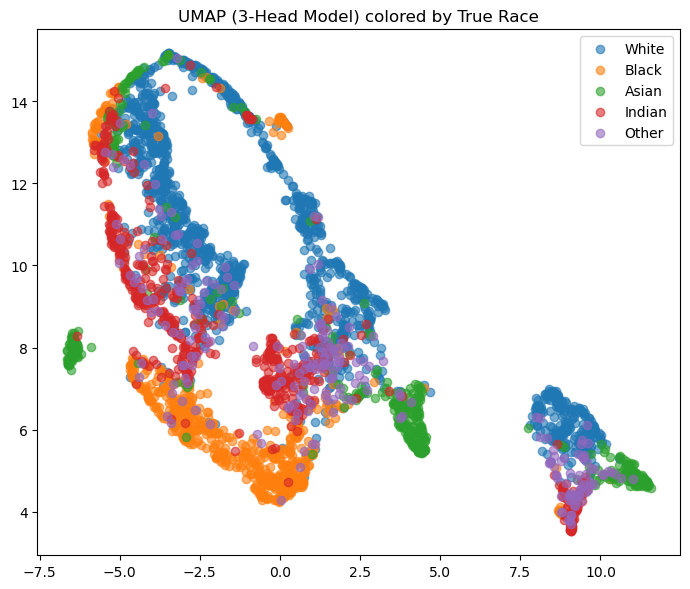

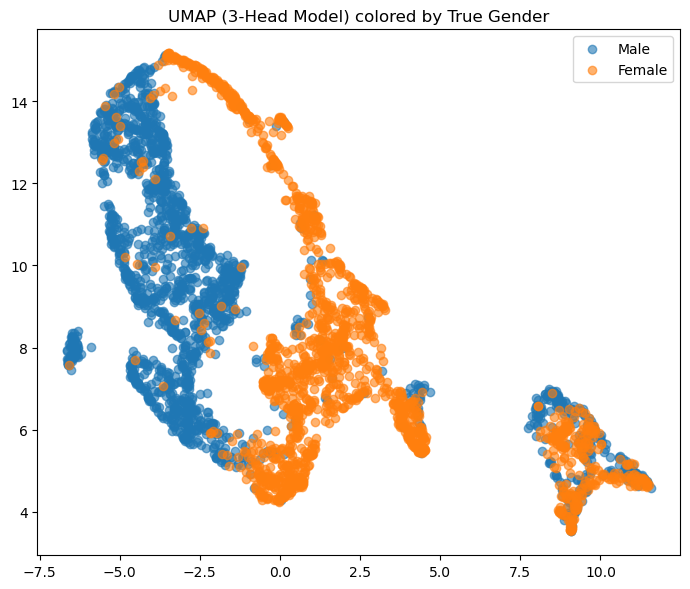

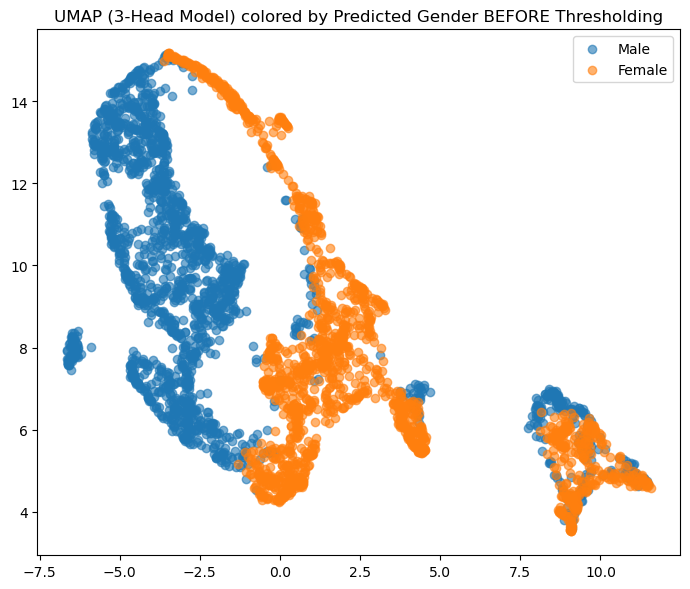

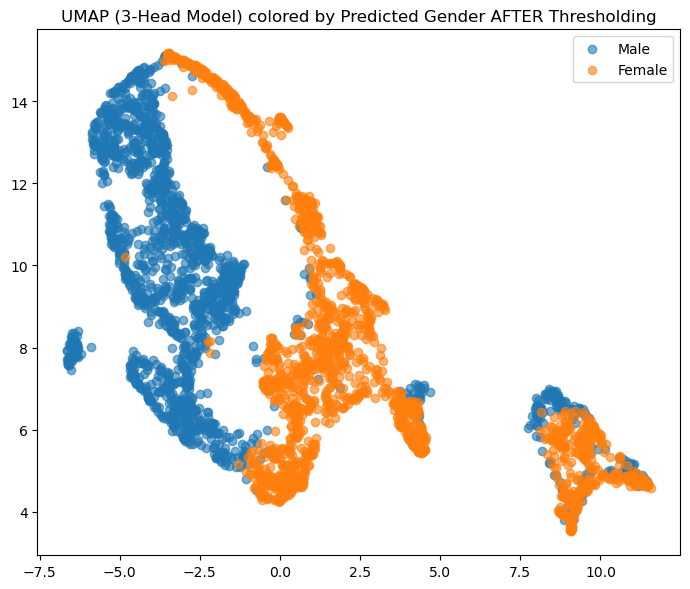

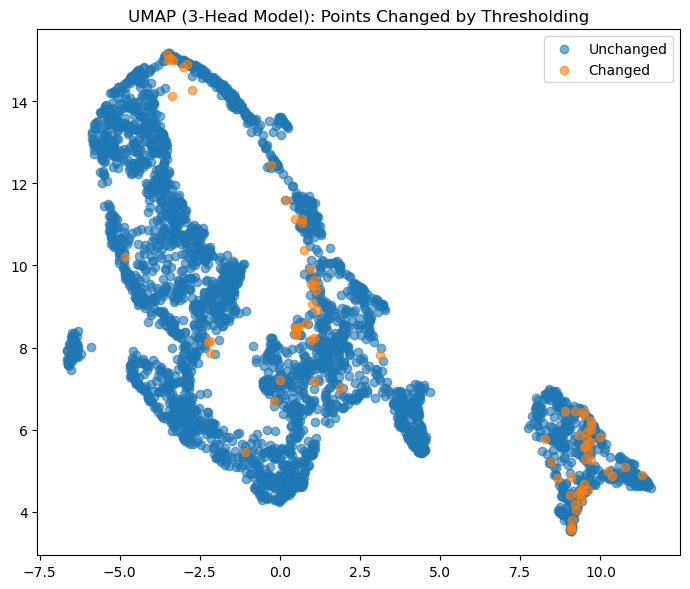

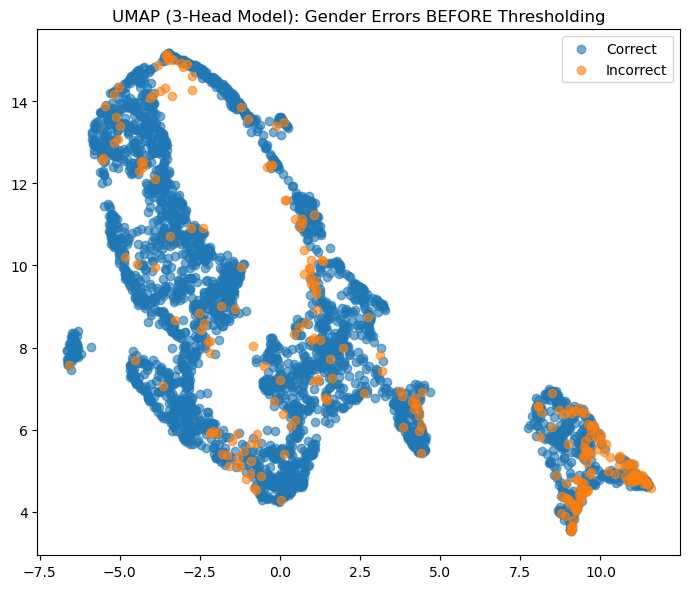

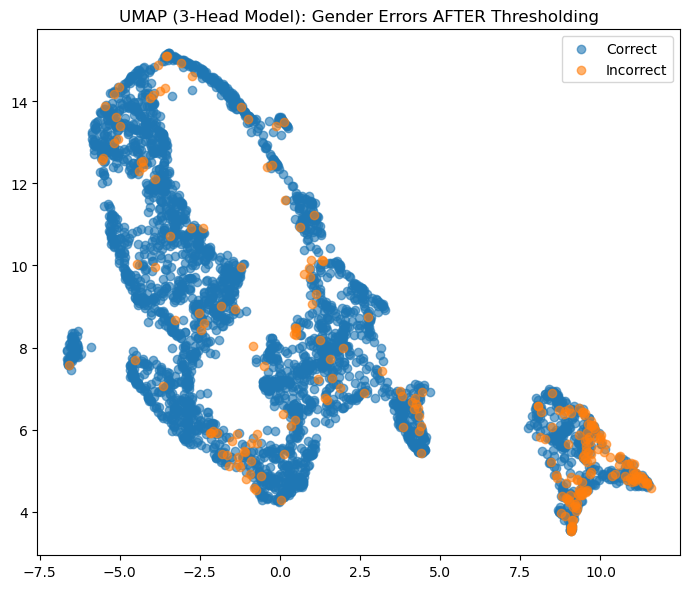

In [95]:
# =========================================================
# 1. EXTRACT EMBEDDINGS + PREDICTIONS FROM 3-HEAD MODEL
# =========================================================

def collect_embeddings_and_predictions(model, loader, device):
    model.eval()

    all_embeddings = []
    results = []

    with torch.no_grad():
        for images, ages, genders, races, age_bins in loader:
            images = images.to(device)

            features = model.backbone(images)

            age_pred = model.age_head(features).squeeze(1)
            gender_logit = model.gender_head(features).squeeze(1)
            race_logits = model.race_head(features)

            gender_prob = torch.sigmoid(gender_logit)
            pred_gender_default = (gender_prob >= 0.5).int()
            pred_race = torch.argmax(race_logits, dim=1)

            all_embeddings.append(features.cpu())

            for i in range(len(images)):
                results.append({
                    "true_age": float(ages[i].item()),
                    "pred_age": float(age_pred[i].item()),
                    "age_error": float(age_pred[i].item() - ages[i].item()),

                    "true_gender_num": int(genders[i].item()),
                    "pred_gender_num": int(pred_gender_default[i].item()),
                    "gender_prob": float(gender_prob[i].item()),

                    "true_race_num": int(races[i].item()),
                    "pred_race_num": int(pred_race[i].item()),

                    "true_race": race_map[int(races[i].item())],
                    "pred_race": race_map[int(pred_race[i].item())],
                    "true_gender": gender_map[int(genders[i].item())],

                    "age_bin": str(age_bins[i])
                })

    emb = torch.cat(all_embeddings, dim=0).numpy()
    df_preds = pd.DataFrame(results)

    return emb, df_preds

    emb = torch.cat(all_embeddings, dim=0).numpy()
    df_preds = pd.DataFrame(results)

    return emb, df_preds


# =========================================================
# 2. APPLY THRESHOLDS TO GET ADJUSTED GENDER PREDICTIONS
# =========================================================

def apply_race_specific_gender_thresholds(results_df, thresholds):
    out = results_df.copy()

    out["gender_threshold"] = out["pred_race_num"].map(thresholds).fillna(0.5)
    out["pred_gender_adjusted"] = (
        out["gender_prob"] >= out["gender_threshold"]
    ).astype(int)

    out["gender_correct_default"] = (
        out["pred_gender_num"] == out["true_gender_num"]
    ).astype(int)

    out["gender_correct_adjusted"] = (
        out["pred_gender_adjusted"] == out["true_gender_num"]
    ).astype(int)

    return out


# =========================================================
# 3. SIMPLE UMAP PLOTTING HELPER
# =========================================================

def plot_umap(X_umap, labels, label_map=None, title=""):
    plt.figure(figsize=(7, 6))

    labels = np.array(labels)
    unique_labels = np.unique(labels)

    for lab in unique_labels:
        mask = labels == lab
        name = label_map[lab] if label_map is not None and lab in label_map else str(lab)

        plt.scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            label=name,
            alpha=0.6
        )

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 4. COLLECT TEST EMBEDDINGS + DEFAULT PREDICTIONS
# =========================================================

embeddings_3head, umap_results = collect_embeddings_and_predictions(
    resnet_model,
    test_loader,
    device
)

# apply thresholding
umap_results = apply_race_specific_gender_thresholds(umap_results, thresholds)


# =========================================================
# 5. RECALCULATE UMAP IN THIS NOTEBOOK
# =========================================================

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap_3head = reducer.fit_transform(embeddings_3head)


# =========================================================
# 6. PLOT TRUE LABELS / DEFAULT / THRESHOLDED / CHANGES
# =========================================================

# true race
plot_umap(
    X_umap_3head,
    umap_results["true_race_num"].values,
    race_map,
    "UMAP (3-Head Model) colored by True Race"
)

# true gender
plot_umap(
    X_umap_3head,
    umap_results["true_gender_num"].values,
    gender_map,
    "UMAP (3-Head Model) colored by True Gender"
)

# default gender prediction
plot_umap(
    X_umap_3head,
    umap_results["pred_gender_num"].values,
    gender_map,
    "UMAP (3-Head Model) colored by Predicted Gender BEFORE Thresholding"
)

# thresholded gender prediction
plot_umap(
    X_umap_3head,
    umap_results["pred_gender_adjusted"].values,
    gender_map,
    "UMAP (3-Head Model) colored by Predicted Gender AFTER Thresholding"
)

# changed vs unchanged
changed = (
    umap_results["pred_gender_num"].values !=
    umap_results["pred_gender_adjusted"].values
).astype(int)

change_map = {0: "Unchanged", 1: "Changed"}

plot_umap(
    X_umap_3head,
    changed,
    change_map,
    "UMAP (3-Head Model): Points Changed by Thresholding"
)

# default errors
default_errors = (
    umap_results["pred_gender_num"].values !=
    umap_results["true_gender_num"].values
).astype(int)

error_map = {0: "Correct", 1: "Incorrect"}

plot_umap(
    X_umap_3head,
    default_errors,
    error_map,
    "UMAP (3-Head Model): Gender Errors BEFORE Thresholding"
)

# adjusted errors
adjusted_errors = (
    umap_results["pred_gender_adjusted"].values !=
    umap_results["true_gender_num"].values
).astype(int)

plot_umap(
    X_umap_3head,
    adjusted_errors,
    error_map,
    "UMAP (3-Head Model): Gender Errors AFTER Thresholding"
)